In [4]:
import jax

jax.config.update("jax_enable_x64", False)
jax.config.update("jax_platform_name", "cpu")
# jax.config.update("jax_platform_name", "gpu")
jax.config.update("jax_debug_nans", True)
print(jax.local_devices()[0].device_kind)

import os
import zodiax as zdx
from zodiax.optimisation import sgd, adam
from jax import numpy as np, random as jr, tree as jtu
import dLux.utils as dlu

import amigo
import dorito

# import astropy

# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl

import ehtplot
import scienceplots
import cmasher as cmr

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

cpu


In [5]:
from socket import gethostname

if gethostname() == "glinton":
    morgana = "/media/morgana1/"
else:
    morgana = "/Volumes/morgana1/"

data_path = os.path.join(morgana, "snert/max/data/JWST/WR137/calslope/")
uncal_path = os.path.join(morgana, "snert/max/data/JWST/WR137/uncal/")
amigo_cache = os.path.join(morgana, "snert/max/data/amigo_files/")

cache = os.path.join(amigo_cache, "cal_files/")
output_path = os.path.join(amigo_cache, "outputs/WR137/")

load_dict = lambda x: np.load(x, allow_pickle=True).item()
cal_vis_outputs = load_dict(os.path.join(output_path, "cal_vis.npy"))

print(cal_vis_outputs.keys())

dict_keys(['F380M_189.8', 'F380M_162.7', 'F480M_189.8', 'F480M_162.7'])


In [6]:
optics = amigo.optical_models.AMIOptics()
otf_coords = dlu.pixel_coords(51, 2 * optics.diameter)

ois = [
    dorito.model_fits.ResolvedOIFit(oi_data, key, filter=key[:5])
    for key, oi_data in cal_vis_outputs.items()
]
# ois = [center_phase(oi) for oi in ois]

# distribution = np.zeros((41, 41)).at[20, 20].set(1.0)  # + 1e-16
distribution = np.ones((121, 121))
# distribution = np.zeros((51, 51)).at[25, 25].set(1.0) + 1e-2

model = dorito.models.ResolvedSickoModel(
    ois,
    distribution,
    uv_npixels=2 * otf_coords.shape[-1],
    uv_pscale=0.5 * np.diff(otf_coords[0, 0]).mean(),
    # oversample=6.0,
    oversample=6.0,
)

params = model.params
for oi in ois:
    dirty_img = oi.dirty_image(model)
    params["log_dist"][oi.get_key("log_dist")] = np.log10(dirty_img / dirty_img.sum())

In [7]:
# oi = ois[0]

# sz = 99
# delta = np.zeros((sz, sz)).at[sz // 2, sz // 2].set(1.0)
# distribution = delta.at[40, 40].set(0.2).at[53, 53].set(0.3)

# delta /= delta.sum()
# distribution /= distribution.sum()

# base_uv = dlu.MFT(
#     phasor=delta + 0j,
#     wavelength=oi.wavel,  # If focal length is None this doesn't do anything
#     pixel_scale_in=model.pscale_in,
#     npixels_out=model.uv_npixels,
#     pixel_scale_out=model.uv_pscale,
# )

# uv = dlu.MFT(
#     phasor=distribution + 0j,
#     wavelength=oi.wavel,  # If focal length is None this doesn't do anything
#     pixel_scale_in=model.pscale_in,
#     npixels_out=model.uv_npixels,
#     pixel_scale_out=model.uv_pscale,
# )

# uv /= base_uv

# plt.figure(figsize=(10, 4))
# plt.subplot(1, 2, 1)
# plt.title(f"{oi.filter} u,v amplitude")
# plt.imshow(np.abs(uv), coolwarm, norm=mpl.colors.CenteredNorm(1.00))
# plt.colorbar()
# plt.subplot(1, 2, 2)
# plt.title(f"{oi.filter} u,v phase")
# plt.imshow(np.angle(uv), seismic, norm=mpl.colors.CenteredNorm())
# plt.colorbar()
# plt.show()


# # TO SICKO
# uv = dlu.downsample(uv, 2, mean=True)
# vis = uv.flatten()[: uv.size // 2]
# vis = np.log(vis)
# log_amp, phase = vis.real, vis.imag
# sicko_amp = np.dot(log_amp, oi.vis_mat)
# sicko_phase = np.dot(phase, oi.phi_mat)

# # FROM SICKO
# # converting to u,v visibilities
# log_vis = np.dot(sicko_amp, np.linalg.pinv(oi.vis_mat))
# phase = np.dot(sicko_phase, np.linalg.pinv(oi.phi_mat))
# vis_im, phase_im = amigo.vis_models.vis_to_im(log_vis, phase, (51, 51))
# uv = np.exp(vis_im + 1j * phase_im)

# plt.figure(figsize=(10, 4))
# plt.subplot(1, 2, 1)
# plt.title(f"{oi.filter} u,v amplitude")
# plt.imshow(np.abs(uv), coolwarm, norm=mpl.colors.CenteredNorm(1.00))
# plt.colorbar()
# plt.subplot(1, 2, 2)
# plt.title(f"{oi.filter} u,v phase")
# plt.imshow(np.angle(uv), seismic, norm=mpl.colors.CenteredNorm())
# plt.colorbar()
# plt.show()


# # Getting the dirty image
# mft_dirty = dlu.MFT(
#     phasor=uv,
#     wavelength=oi.wavel,
#     pixel_scale_in=2 * model.uv_pscale,
#     npixels_out=distribution.shape[0],
#     pixel_scale_out=model.pscale_in,
#     inverse=True,
# )

# dirty = np.abs(mft_dirty)
# dirty /= dirty.sum()

# print(dirty.sum())

# plt.figure(figsize=(10, 4))
# plt.subplot(1, 2, 1)
# plt.imshow(distribution, "inferno", norm=mpl.colors.PowerNorm(0.3))
# plt.title("Distribution")
# plt.colorbar()
# plt.subplot(1, 2, 2)
# plt.imshow(dirty, "inferno", norm=mpl.colors.PowerNorm(0.3))
# plt.title("Dirty Image")
# plt.colorbar()
# plt.show()

In [8]:
# fig, ax = plt.subplots(1, 1)
# im = dorito.plotting.plot_result(
#     ax,
#     ois[0].dirty_image(model, model.get_distribution(ois[0]).shape[0]),
#     dlu.rad2arcsec(model.pscale_in),
# )
# fig.colorbar(im, ax=ax)
# ax.set_title("Dirty Image")
# plt.show()

In [9]:
# for oi in ois:
#     dist = model.get_distribution(oi)
#     plt.imshow(dist)
#     plt.colorbar()
#     plt.show()

In [ ]:
import jax.scipy as jsp
import jax.random as jr


def difflim_to_cov(model, exposure, factor):

    # calculating lambda over D
    D = 6.603464  # m
    lambda_on_D = dlu.rad2arcsec(exposure.wavel / D)

    # calculating sigma, with some factor in front of lambda on D
    sigma = dorito.misc.fwhm_to_sigma(factor * lambda_on_D)

    # return covariance matrix
    return [[sigma**2, 0], [0, sigma**2]]


def blur_distribution(array, model, exposure, extent=0.25, factor=1.0):
    cov = difflim_to_cov(model, exposure, factor)

    x = np.arange(-extent, extent, dlu.rad2arcsec(model.pscale_in))
    X, Y = np.meshgrid(x, x)
    pos = np.dstack((X, Y))

    kernel = jsp.stats.multivariate_normal.pdf(jr.PRNGKey(0), pos, np.array(cov))

    distribution = jsp.signal.convolve2d(
        array,
        kernel,
        mode="same",
        # method="fft",
    )
    return distribution / distribution.sum()


# def normalise_distribution(model_params, args):
#     params = model_params.params
#     if "log_dist" in params.keys():
#         for k, log_dist in params["log_dist"].items():
#             distribution = 10**log_dist
#             params["log_dist"][k] = np.log10(distribution / distribution.sum())

#     return model_params.set("params", params), args


def normalise_distribution(model_params, args):
    params = model_params.params

    if "log_dist" in params.keys():
        for k, log_dist in params["log_dist"].items():
            distribution = 10**log_dist

            # centre = distribution.shape[0] // 2
            # norm = distribution[centre, centre]

            norm = distribution.sum()

            params["log_dist"][k] = np.log10(distribution / norm)

    return model_params.set("params", params), args


def grad_fn(model, grads, args):

    threshold = 1e-5

    params = grads.params
    if "log_dist" in params.keys():
        for k, grad in params["log_dist"].items():
            grad = np.clip(grad, threshold, threshold)
            params["log_dist"][k] = grad

    return grads.set("params", params), args


def looper(looper, loss_dict):
    loss = np.array([v[-1] for v in loss_dict.values()]).mean(0)
    looper.set_description(f"Loss: {loss:.3e}")


def log_likelihood(model, oi, args={}):
    data = np.concatenate([oi.vis, oi.phi])
    err = np.concatenate([oi.d_vis, oi.d_phi])
    model_vis = np.concatenate([*oi(model)])
    # model_vis = oi(model).flatten()

    # chi2 = np.sum(jax.scipy.stats.norm.logpdf(data, loc=model_vis, scale=err))
    loglike = np.sum(((data - model_vis) / err) ** 2)

    return loglike


def apply_regularisers(model, exposure, args):
    # creating a list of regularisation functions and regularisation hyperparameters
    fn_list = [args["reg_func_dict"][reg] for reg in args["reg_dict"].keys()]
    coeff_list = list(args["reg_dict"].values())

    # evaluating the regularisation term with each for each regulariser
    priors = [
        coeff * fn(model, exposure, args) for coeff, fn in zip(coeff_list, fn_list)
    ]
    prior = np.array(priors).sum()  # summing the different regularisers

    return prior


def calc_loglike_prior(model, exposure, args):
    # this is per exposure

    # regular likelihood term
    likelihood = np.nanmean(log_likelihood(model, exposure))

    # grabbing and exponentiating log distributions
    prior = apply_regularisers(model, exposure, args)

    return likelihood, prior


def regularised_loss_fn(model, exposure, args={"reg_func_dict": {}, "reg_dict": {}}):
    # this is per exposure
    likelihood, prior = calc_loglike_prior(model, exposure, args)
    return likelihood + prior, ()
    # return likelihood + prior


def phase_centre(model, oi, args={}):

    distribution = model.get_distribution(oi)

    # Tip/Tilt vectors (ramp in u,v)
    mu = oi.u / np.linalg.norm(oi.u)
    mv = oi.v / np.linalg.norm(oi.v)

    # to log visibilities
    _log_amp, phase = oi.to_logvis(model, distribution)

    # calculating the phase centre of the distribution
    return np.hypot(np.dot(mu, phase), np.dot(mv, phase))


def centered_loss_fn(model, exposure, args, width=1e-3):
    likelihood, prior = calc_loglike_prior(model, exposure, args)

    # phase centre prior
    centre = phase_centre(model, exposure, args)
    prior += -jax.scipy.stats.norm.logpdf(centre, loc=0.0, scale=width)

    return likelihood + prior, ()


import equinox as eqx
import optimistix as optx


def BFGS_logdist(model, exposures, reg_args, max_steps=2**14):

    @eqx.filter_jit
    def fun(y, args):

        # unwrapping the args
        model, exp, reg_args = args

        # input is the log distribution
        log_dist = y

        # setting the model to the new log distribution
        params = model.params
        params["log_dist"][exp.get_key("log_dist")] = log_dist
        model = model.set("params", params)

        # calculating loss
        loss, _ = regularised_loss_fn(model, exp, reg_args)

        sum_prior = -jax.scipy.stats.norm.logpdf(
            model.get_distribution(exp).sum(), loc=1.0, scale=1e-5
        )

        return loss + sum_prior

    args_out = {}
    sols_out = {}
    for exp in exposures:

        X = model.params["log_dist"][exp.get_key("log_dist")]
        args = (model, exp, reg_args)
        args_out[exp.key] = args

        print("Initial loss:", fun(X, args))
        solver = optx.BFGS(rtol=1e-4, atol=1e-4)  # , verbose=frozenset({"loss"}))
        sol = optx.minimise(fun, solver, X, args, throw=False, max_steps=max_steps)
        sols_out[exp.key] = sol

        print("Final loss:", fun(sol.value, args))
        print(sol.stats["num_steps"], sol.state.num_accepted_steps)
        print(optx.RESULTS[sol.result])
        print()

    params = model.params
    for exp in ois:
        log_dist = sols_out[exp.key].value
        params["log_dist"][exp.get_key("log_dist")] = log_dist

    return model.set("params", params)

In [11]:
# oi = ois[0]
# # distribution = np.zeros((121, 121)).at[80, 60].set(1.0)
# distribution = result.model.get_distribution(oi)

# otf = oi.to_otf(model, distribution)

# amp_im = np.abs(otf)
# phase_im = np.angle(otf)


# plt.figure(figsize=(10, 4))
# plt.subplot(1, 2, 1)
# plt.title("Amplitude")
# plt.imshow(amp_im, inferno)
# plt.colorbar()
# plt.subplot(1, 2, 2)
# plt.title("Phase")
# plt.imshow(phase_im, "twilight")
# plt.colorbar()
# plt.show()

# plt.figure(figsize=(2, 2))
# plt.imshow(distribution, "inferno")
# # plt.colorbar()
# plt.title("Distribution")
# plt.axis("off")
# plt.show()

# log_amp, phase = oi.to_logvis(model, distribution)

# # Transform to the sicko basis
# sicko_amp = np.dot(log_amp, oi.vis_mat)
# sicko_phase = np.dot(phase, oi.phi_mat)

# print(sicko_amp[-2], sicko_phase[-2])
# print(sicko_amp[-1], sicko_phase[-1])

In [12]:
# # @zdx.filter_jit
# @zdx.filter_grad("log_dist")
# def loss(model_params, model, exposure, args={"reg_func_dict": {}, "reg_dict": {}}):
#     model = model_params.inject(model)
#     return regularised_loss_fn(model, exposure, args)[0]


# # loss(model, ois[0])

# import optax

# jax.config.update("jax_debug_nans", True)


# config = {"log_dist": sgd(1e-1000, 0)}

# model_params = amigo.core_models.ModelParams({p: model.get(p) for p in config.keys()})

# opt_state = solver.init(params)
# for i in range(5):
#     print(f"Iteration {i + 1}")
#     grad = loss(model_params, model, ois[0])
#     updates, opt_state = solver.update(grad, opt_state, model_params)
#     model_params = zdx.apply_updates(model_params, updates)

#     # plt.imshow(model_params.params["log_dist"][ois[0].get_key("log_dist")], inferno)
#     # plt.colorbar()
#     # plt.title("Log Distribution")
#     # plt.show()

#     plt.imshow(grad.params["log_dist"][ois[0].get_key("log_dist")], inferno)
#     plt.colorbar()
#     plt.title("Log Distribution")
#     plt.show()

In [14]:
jax.config.update("jax_debug_nans", True)
import optax

n_epoch = 5000

config = {
    # "log_dist": sgd(1e-8, 0, (3000, 0.1)),
    # "log_dist": sgd(3e-800, 0),
    "log_dist": optax.sgd(1e-10, 0),
    # "log_dist": sgd(5e-8, 0)  # (100, 10), (2000, 0.5)),
    # "log_dist": adam(1e-2, 0, (500, 2)),
    # "log_dist": sgd(5e-9, 0, (500, 2), (1000, 2)),
    # "log_dist": sgd(1e-8, 0, (10, 5), (500, 0.25), (1000, 1.5), (1300, 0.75)),
}

args = {
    "reg_func_dict": {
        "ME": dorito.stats.ME,
        "TV": dorito.stats.TV,
        "L2": dorito.stats.L2,
        "TSV": dorito.stats.TSV,
    },
    "reg_dict": {
        "ME": 1e5,
        # "TV": 1.0,
        # "L2": 1e-5,
        # "TSV": 5e6,
    },
}

trainer = amigo.fitting.Trainer(
    # trainer = Trainer(
    # loss_fn=regularised_loss_fn,
    loss_fn=centered_loss_fn,
    # cache=fisher_cache,
    # grad_fn=grad_fn,s
    norm_fn=normalise_distribution,
    looper_fn=looper,
)

trainer = trainer.update_fishers(
    model=model,
    exposures=[],
    parameters=[],
)

# Train the model
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    batches=ois,
    args=args,
    # batches=exposures,
)

0it [00:00, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 64,367,784.00
Estimated run time: 0:06:45
Full Time: 0:07:35
Final Loss: 1,815,898.75


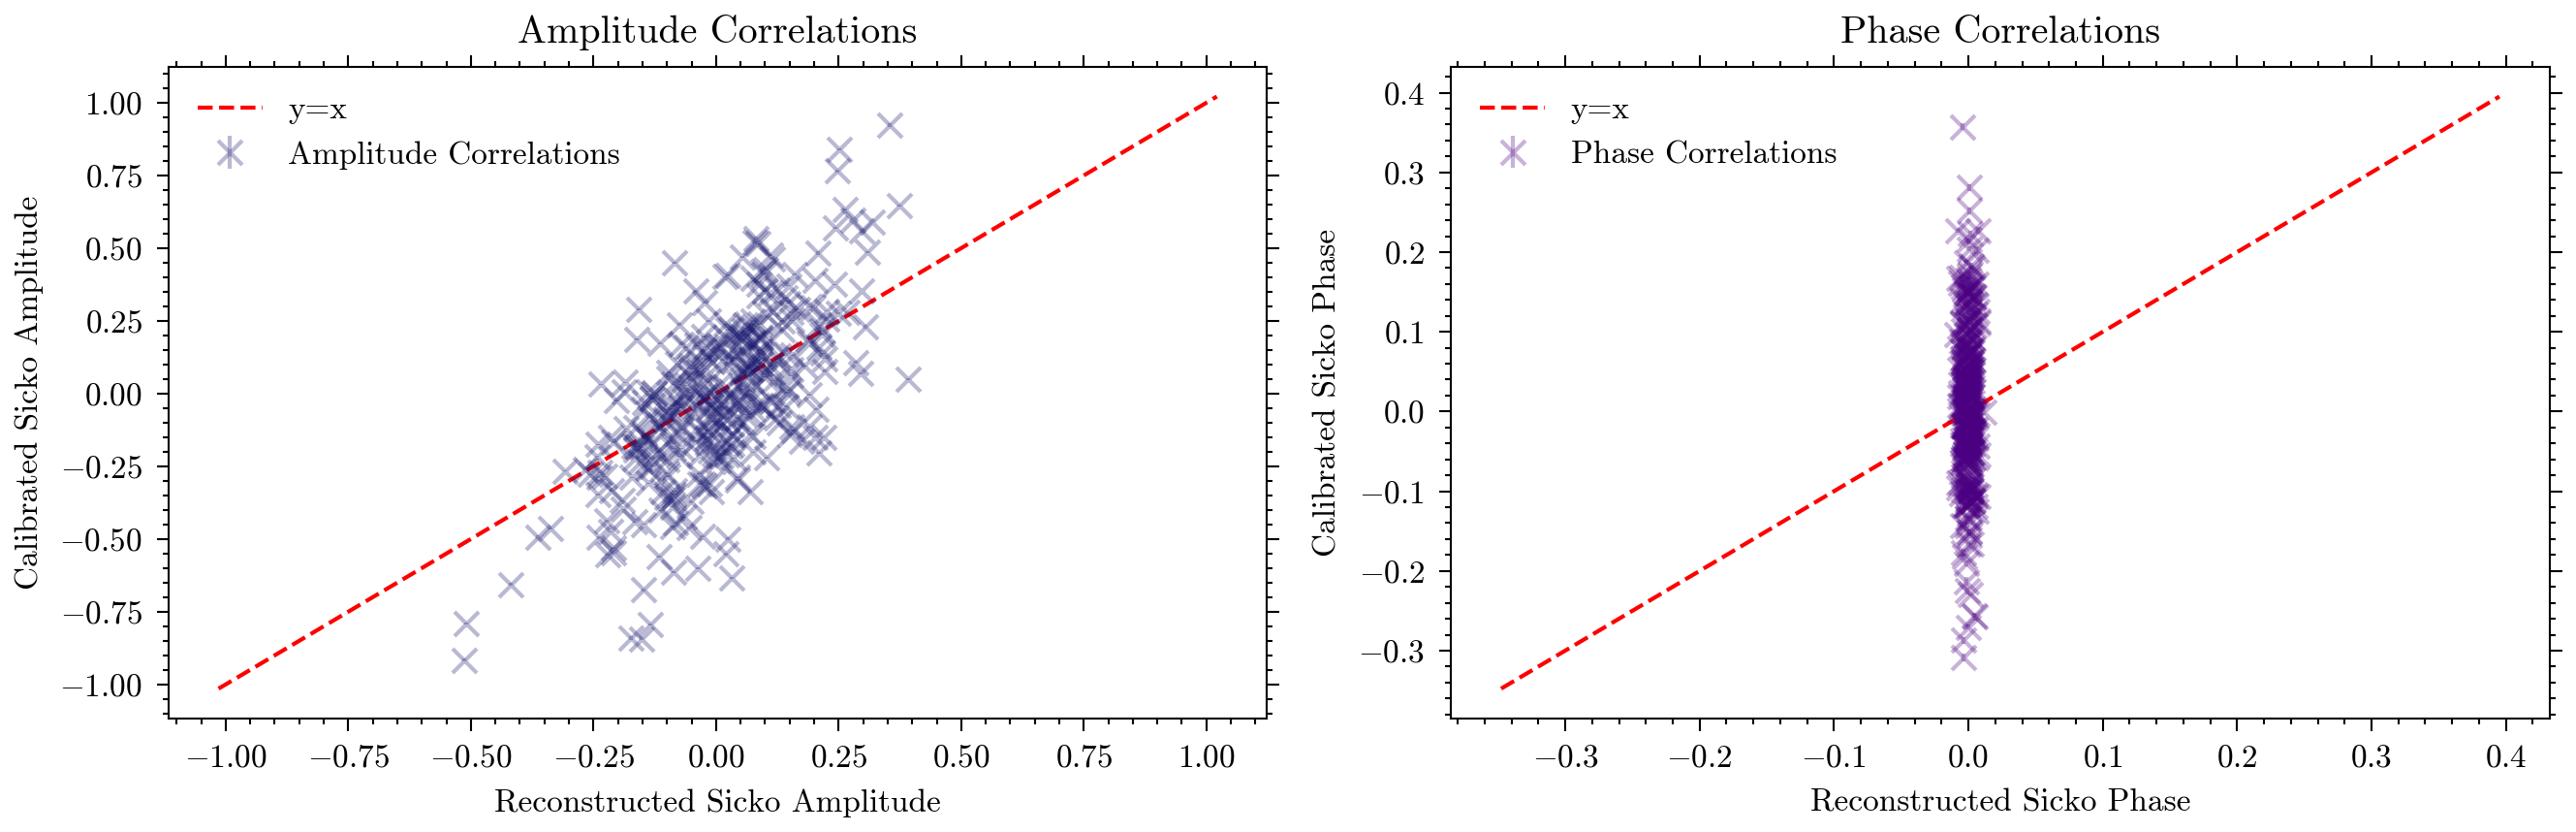

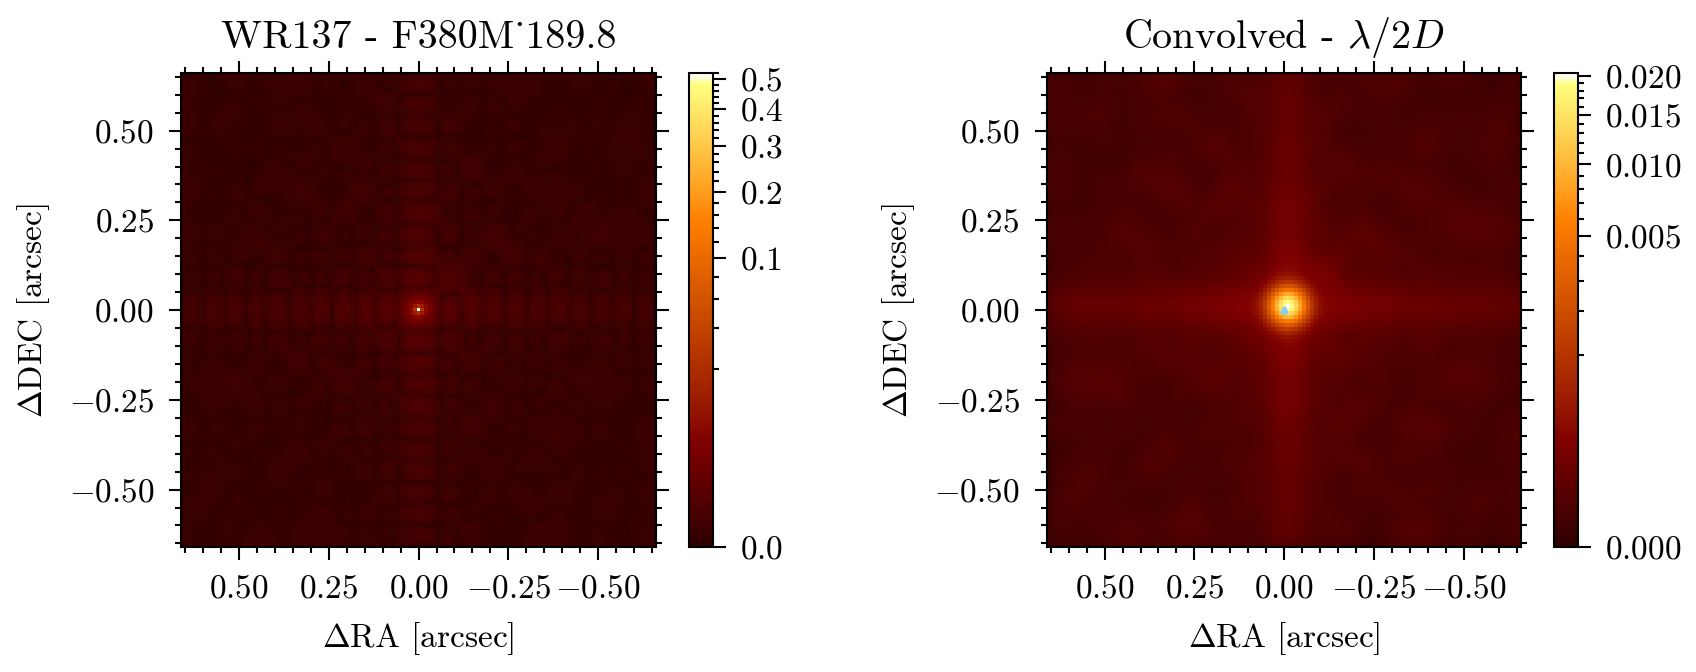

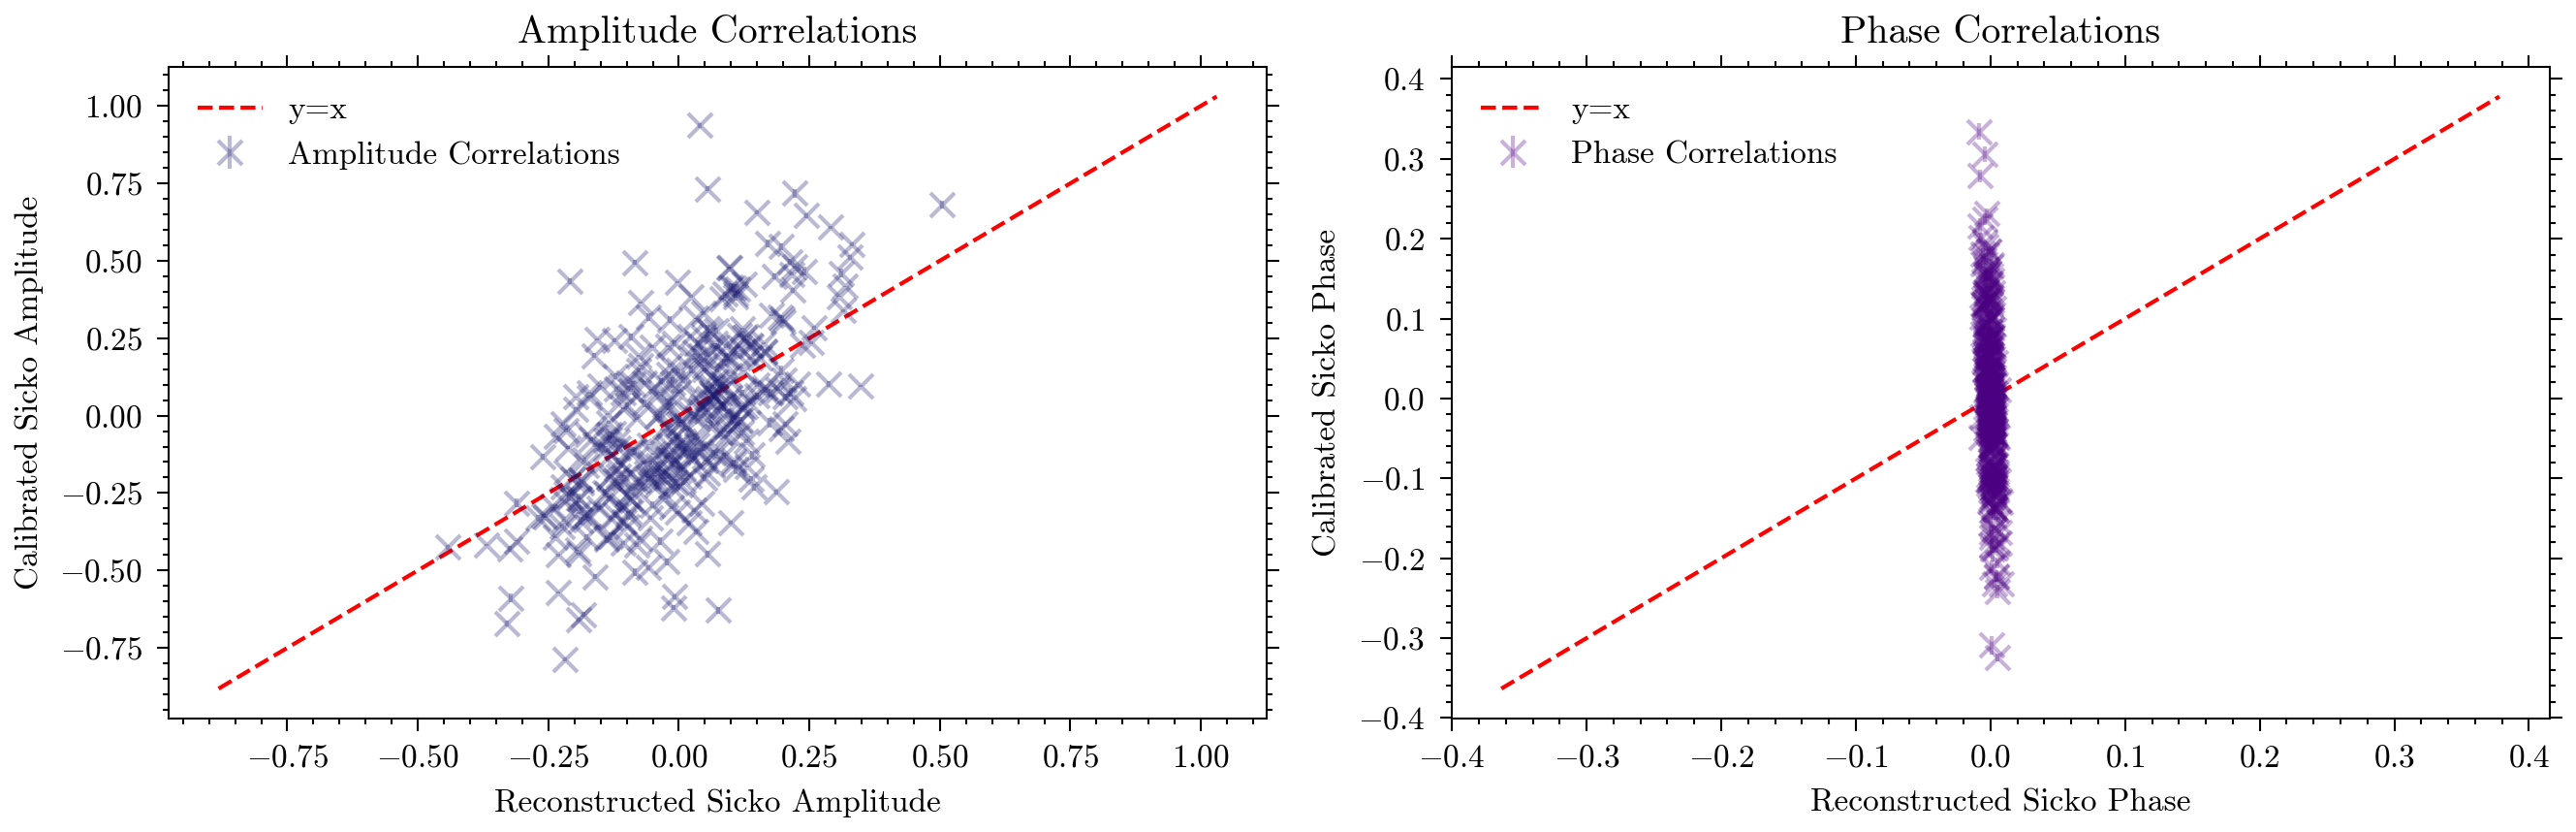

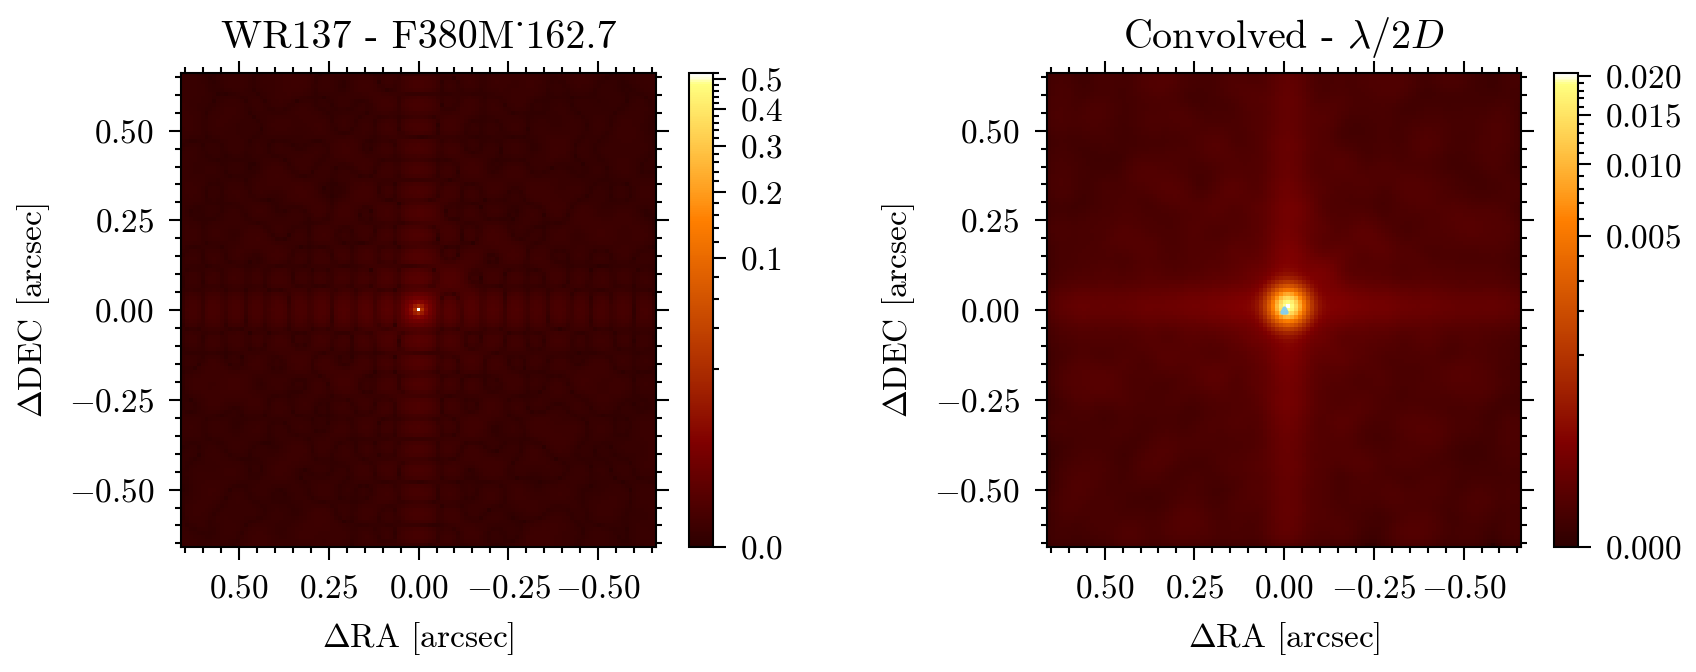

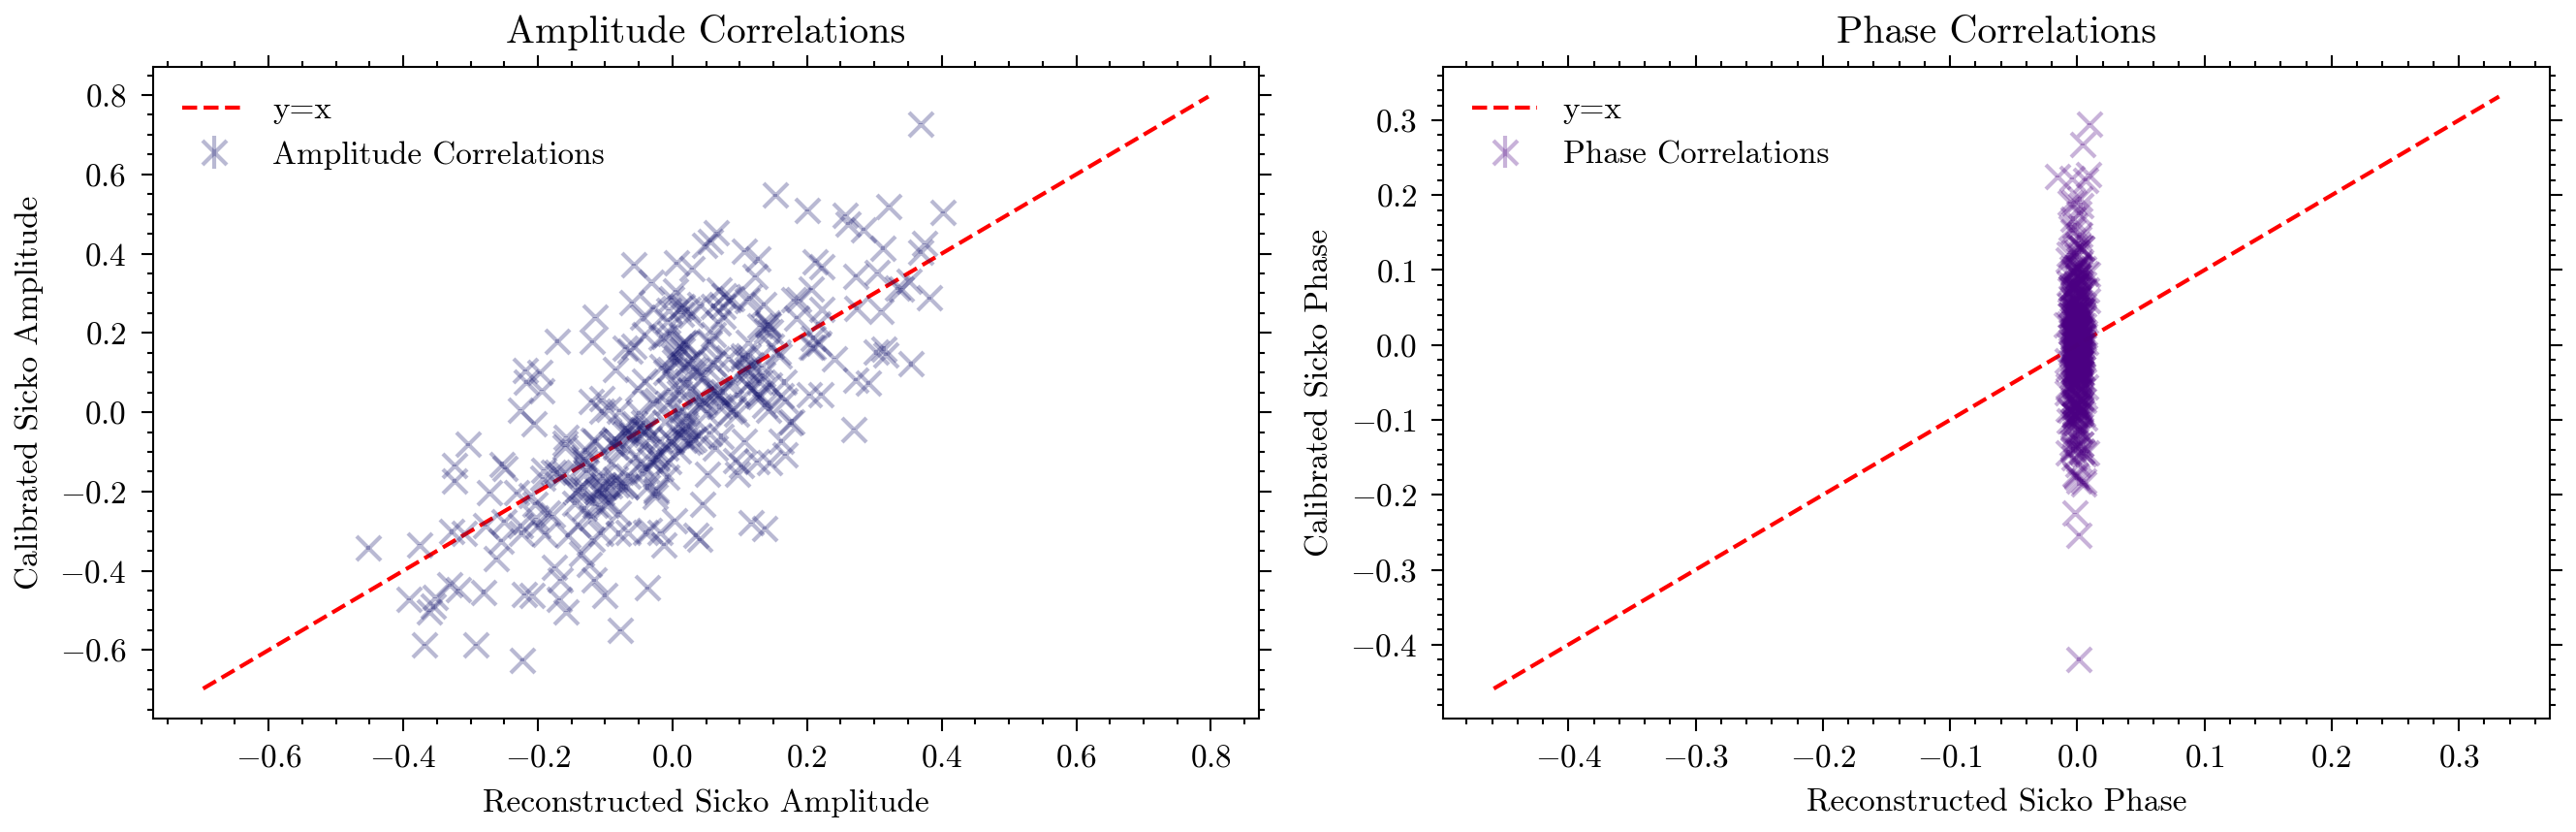

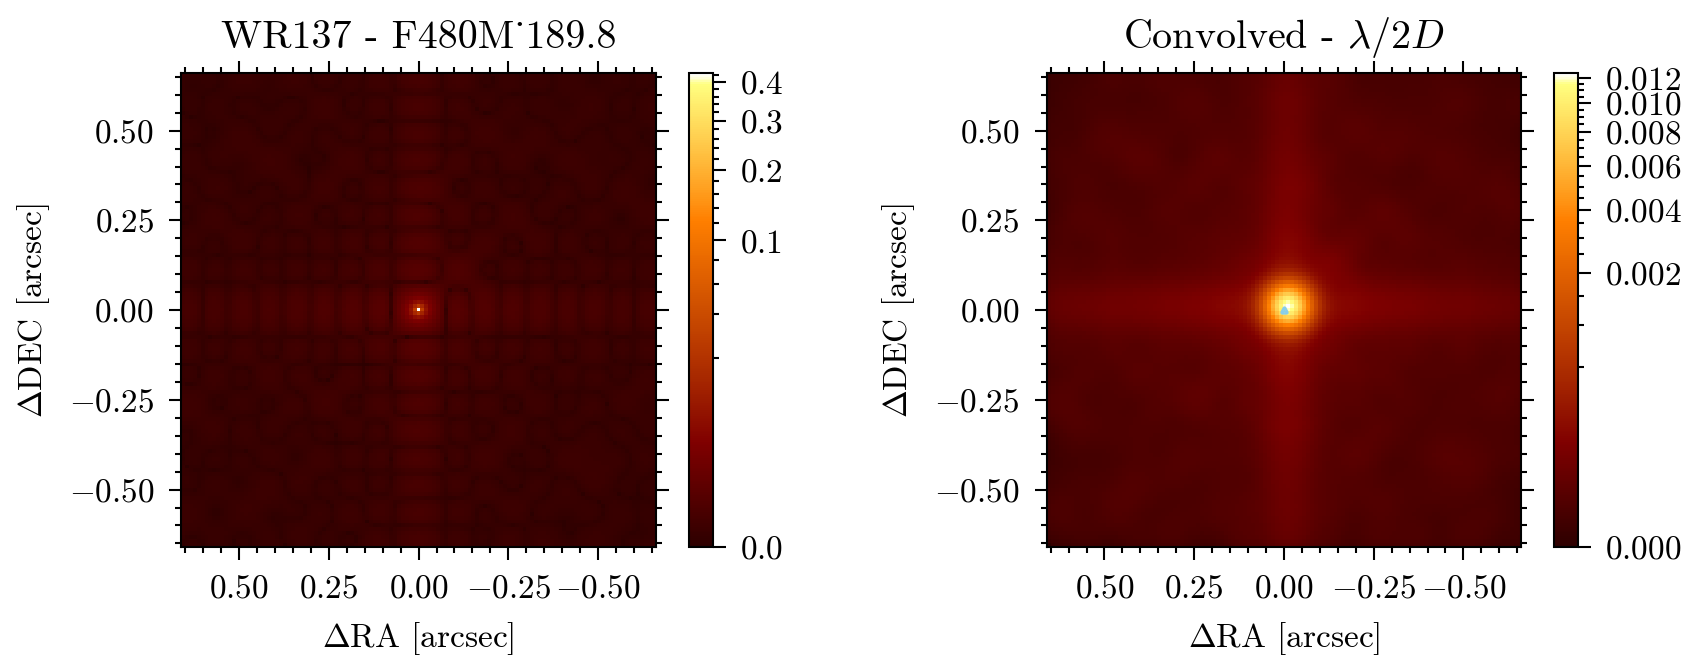

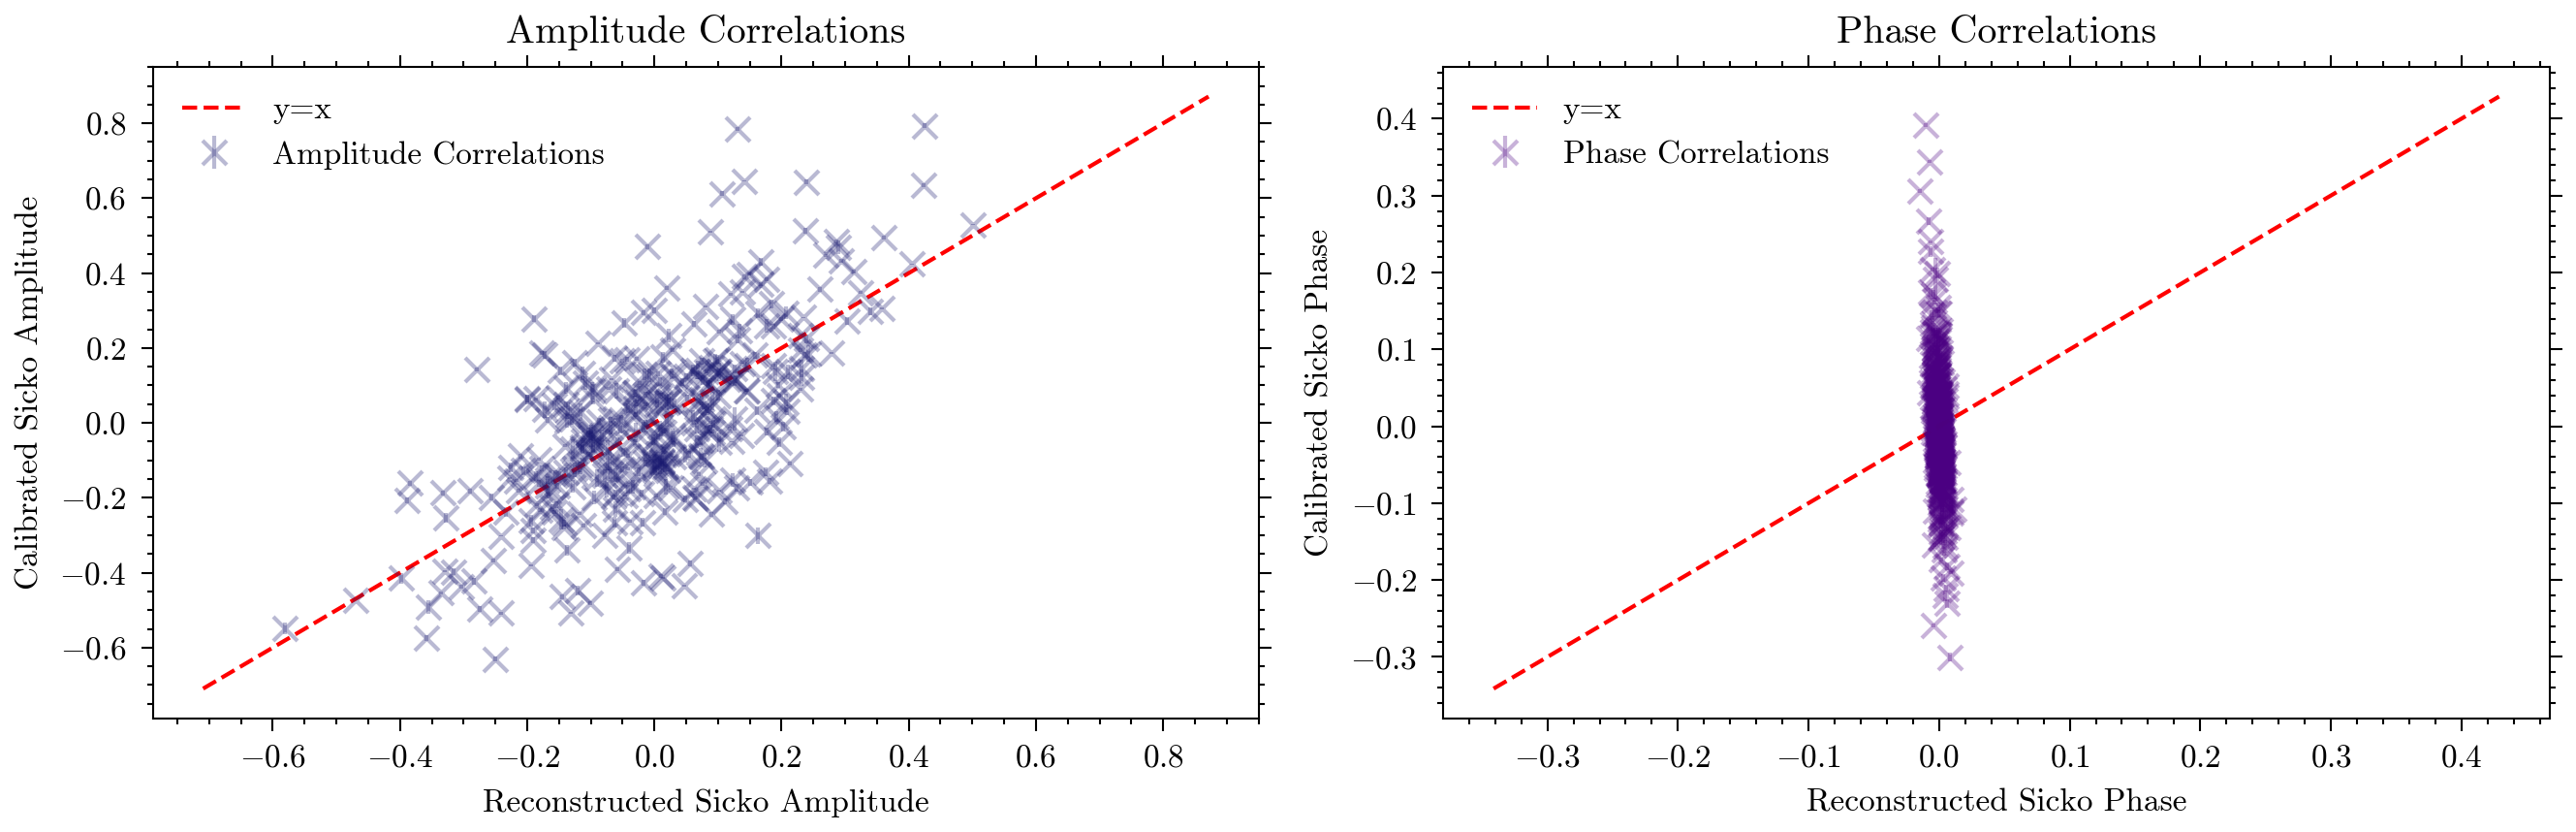

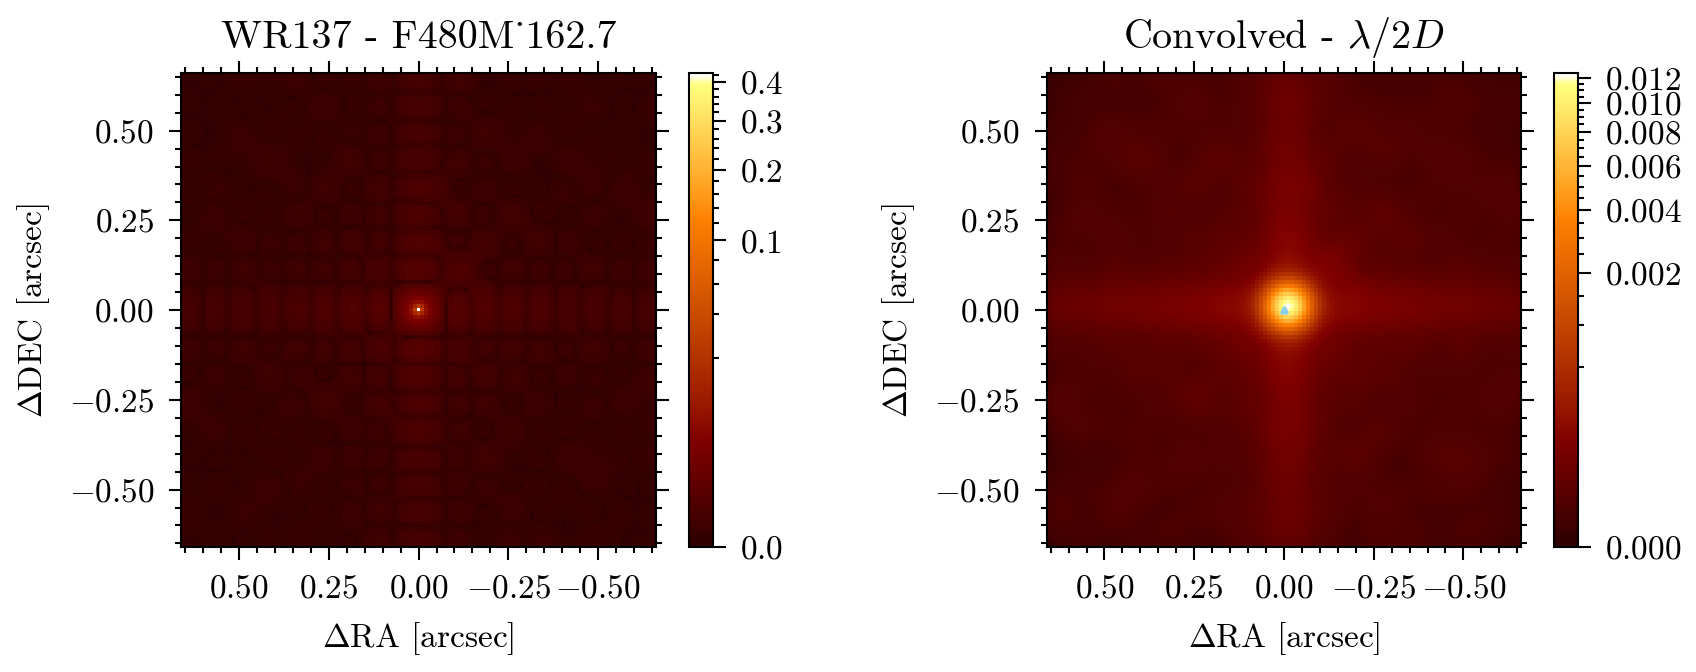

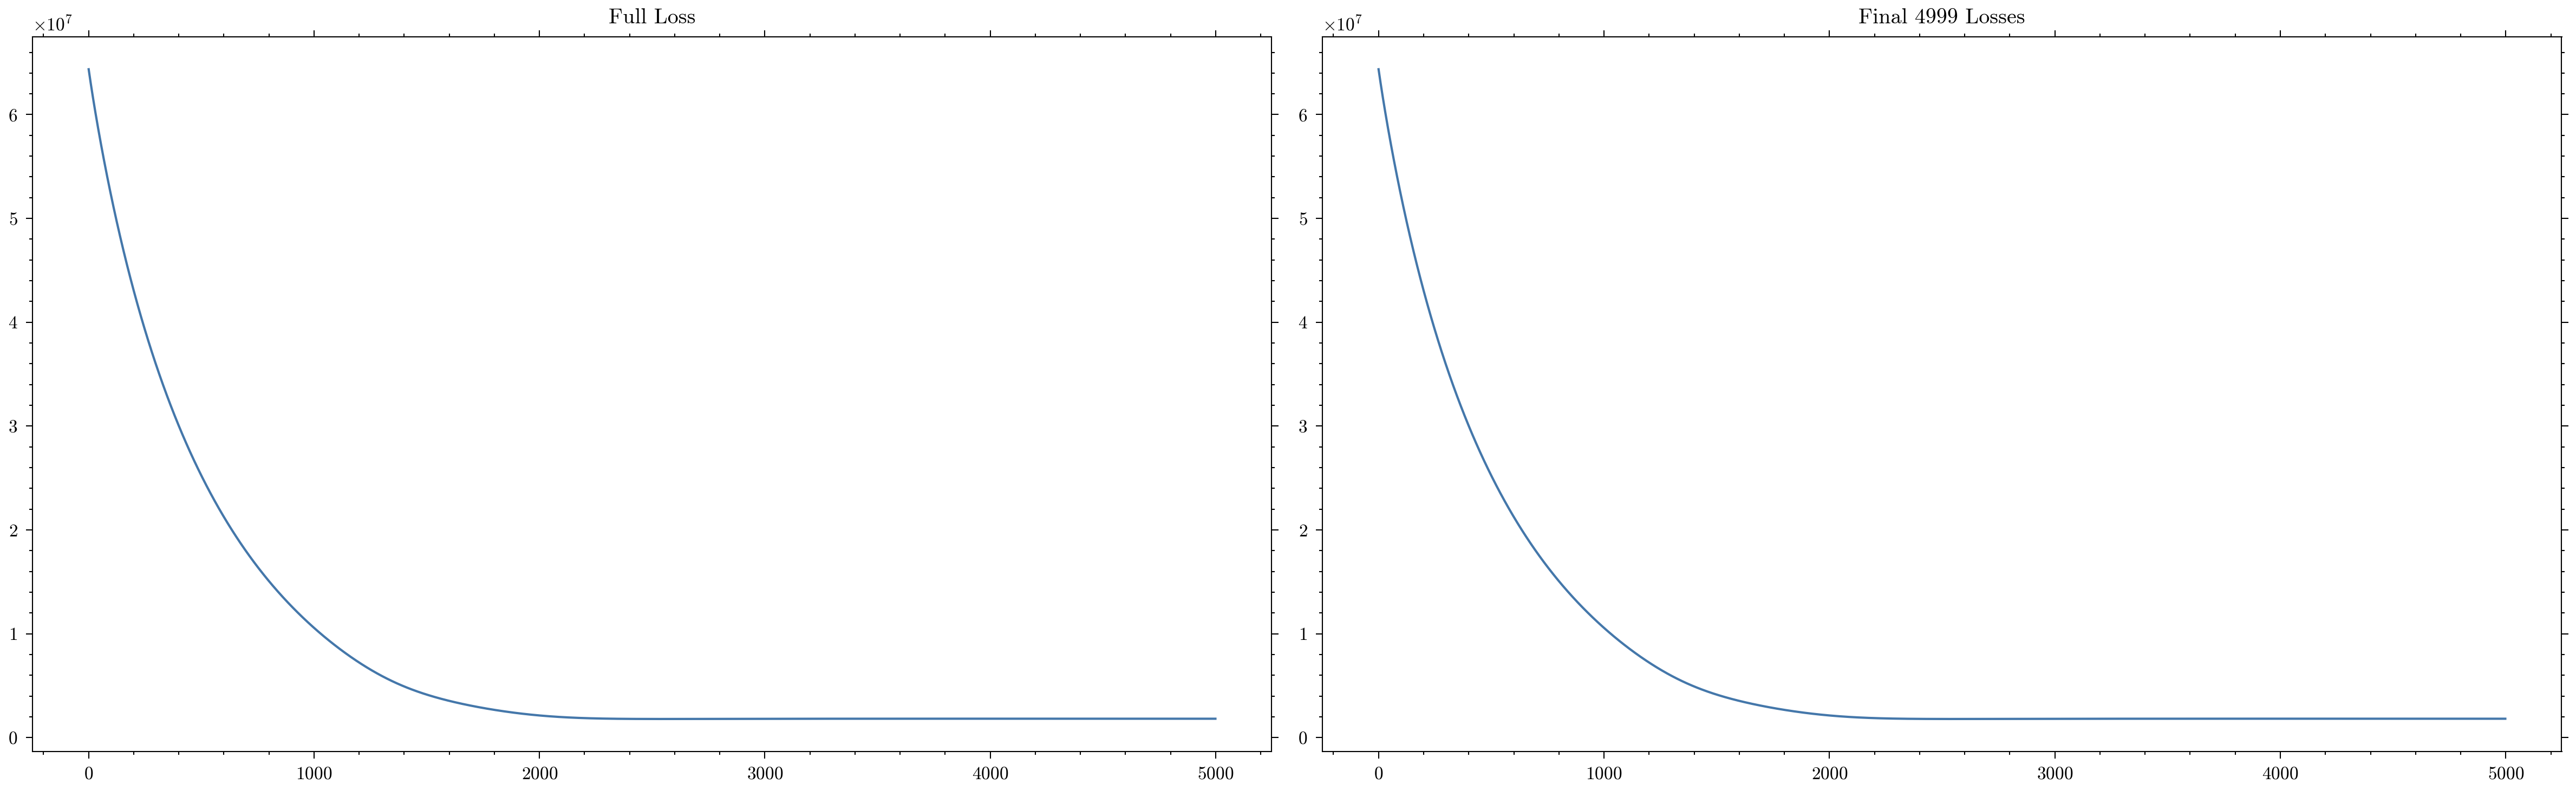

KeyboardInterrupt: 

In [ ]:
for oi in ois:
    dist = 10 ** result.model.params["log_dist"][oi.get_key("log_dist")]

    sicko_amp, sicko_phase = oi(result.model)

    fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharey=False)

    ax[0].errorbar(
        sicko_amp,
        oi.vis,
        yerr=oi.d_vis,
        label="Amplitude Correlations",
        fmt="x",
        alpha=0.3,
        color="midnightblue",
    )
    x_min, x_max = ax[0].get_xlim()
    y_min, y_max = ax[0].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[0].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[0].set_title("Amplitude Correlations")
    ax[0].set_xlabel("Reconstructed Sicko Amplitude")
    ax[0].set_ylabel("Calibrated Sicko Amplitude")
    ax[0].legend()

    ax[1].errorbar(
        sicko_phase,
        oi.phi,
        yerr=oi.d_phi,
        label="Phase Correlations",
        fmt="x",
        alpha=0.3,
        color="indigo",
    )
    x_min, x_max = ax[1].get_xlim()
    y_min, y_max = ax[1].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[1].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[1].set_title("Phase Correlations")
    ax[1].set_xlabel("Reconstructed Sicko Phase")
    ax[1].set_ylabel("Calibrated Sicko Phase")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    ticks = [-0.5, -0.25, 0, 0.25, 0.5]

    fig, ax = plt.subplots(1, 2, figsize=(6, 2.3))

    c0 = dorito.plotting.plot_result(
        ax[0],
        dist,
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_10u",
        power=0.3,
        vmin=0,
        ticks=ticks,
    )
    # ax[0].scatter([0], [0], marker="^", color="skyblue", s=1)

    c1 = dorito.plotting.plot_result(
        ax[1],
        blur_distribution(dist, model, oi, factor=0.5),
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_10u",
        power=0.3,
        vmin=None,
        ticks=ticks,
    )
    ax[1].scatter([0], [0], marker="^", color="skyblue", s=1)
    fig.colorbar(c1, ax=ax[1])

    fig.colorbar(c0)
    # pa = model.params["position_angles"][exp.key]
    ax[0].set_title(
        f"WR137 - {oi.key}"  # - {model.params['position_angles'][exp.get_key('position_angles')]:.1f}deg"
    )
    ax[1].set(title=r"Convolved - $\lambda / 2D$")

    plt.tight_layout()
    # plt.savefig(output_path + f"{time}.png", dpi=300)
    # plt.close()
    plt.show()

amigo.plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
amigo.plotting.plot(result.history)

In [16]:
bfgs_model = BFGS_logdist(
    model=result.model, exposures=ois, reg_args=args, max_steps=2**16
)

Initial loss: 3630580.8
Final loss: 3630566.8
34 2


Initial loss: 524596.3
Final loss: 524594.75
35 2


Initial loss: 2846579.2
Final loss: 2846560.8
33 2


Initial loss: 261791.75
Final loss: 261790.9
34 2




In [17]:
print(bfgs_model.get_distribution(ois[0]).sum())
print(phase_centre(bfgs_model, ois[0]))

0.9999753
0.0017275681


In [18]:
# np.save("files/71pix_os5.npy", bfgs_model.params, allow_pickle=True)
# np.save(output_path + "71pix_os5.npy", bfgs_model.params, allow_pickle=True)
# np.save(output_path + "121pix_os8.npy", bfgs_model.params, allow_pickle=True)

# params = np.load(output_path + "121pix_os8.npy", allow_pickle=True).item()
# bfgs_model = model.set("params", params)

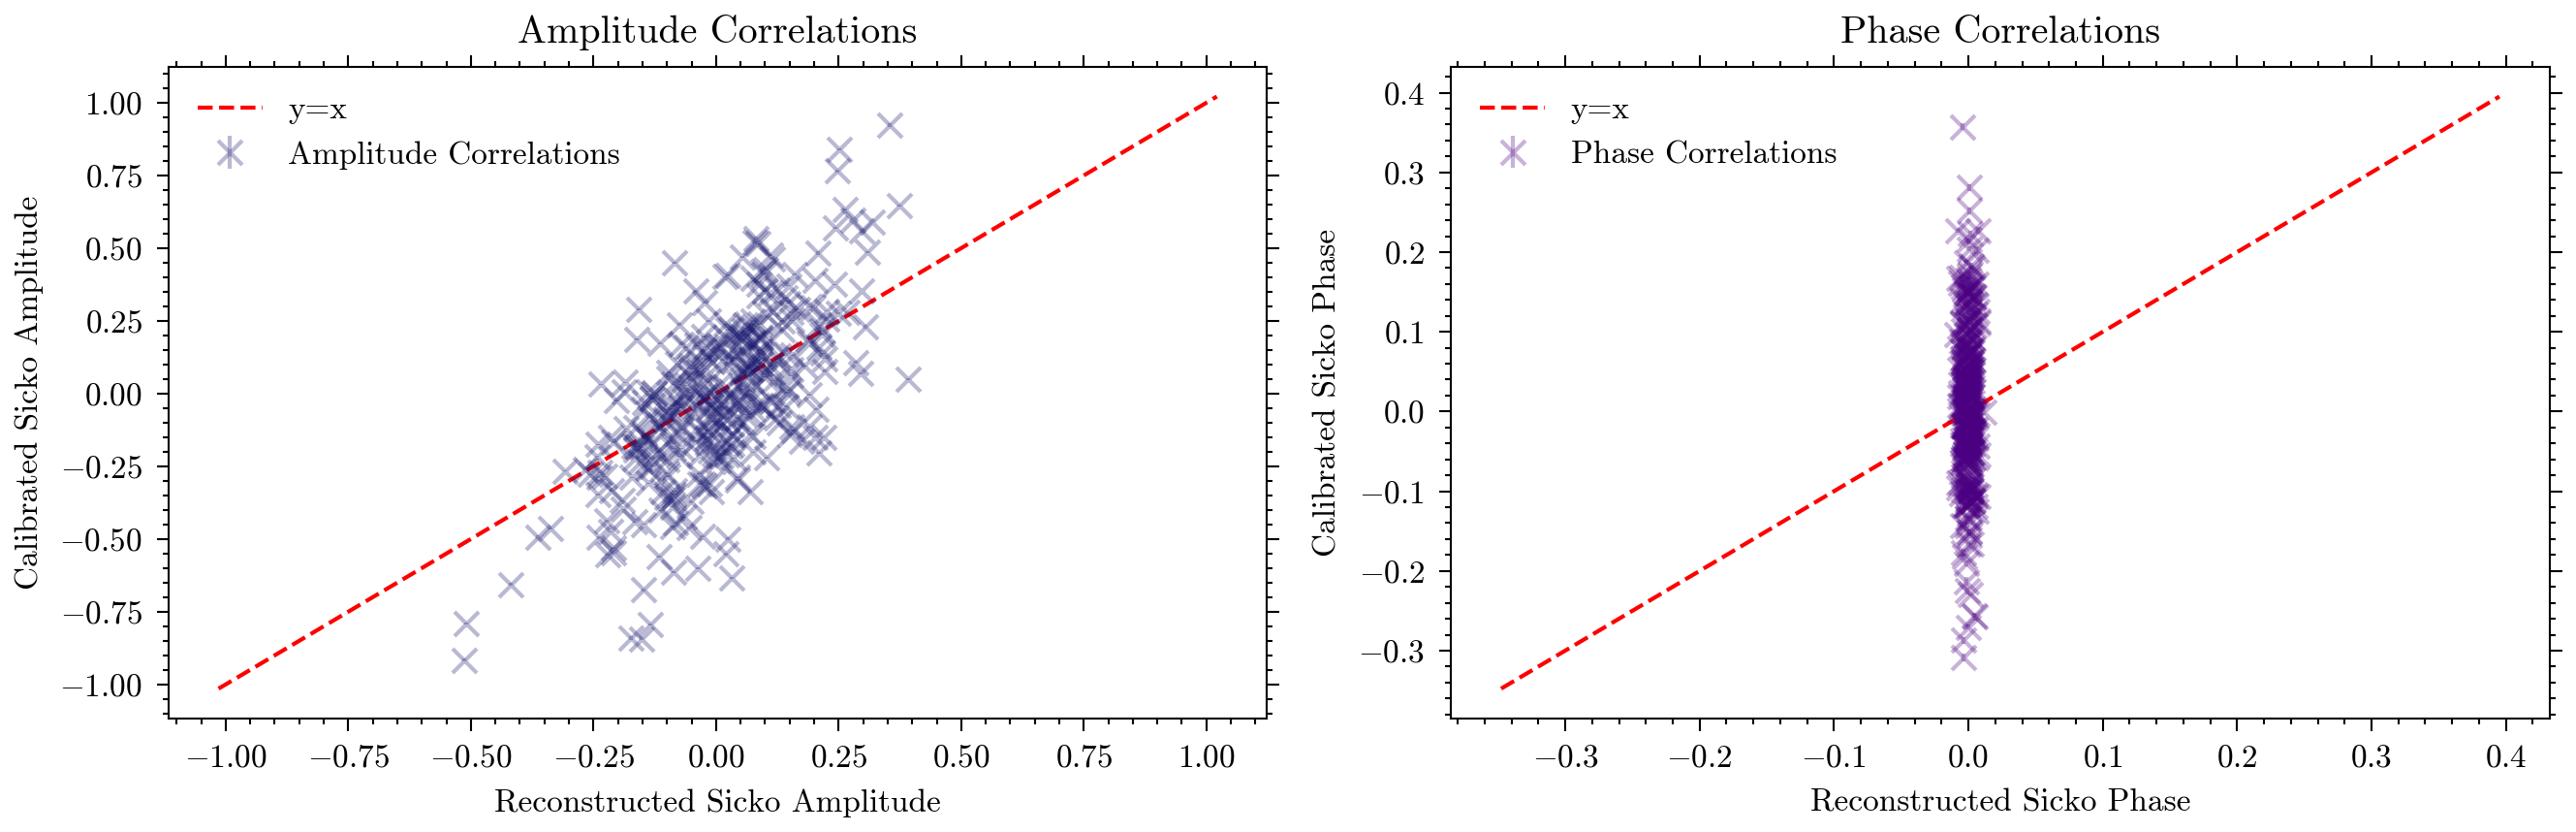

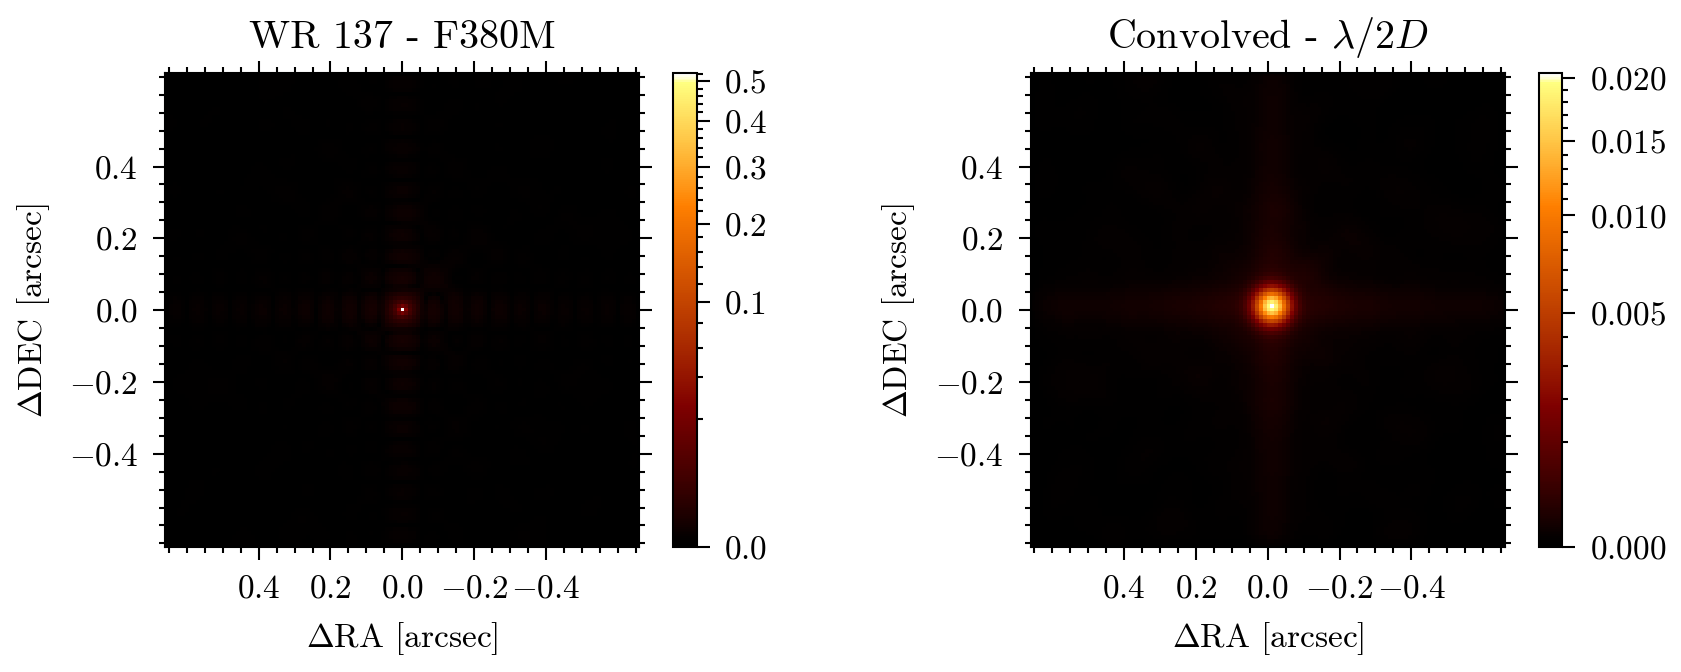

0.9999753


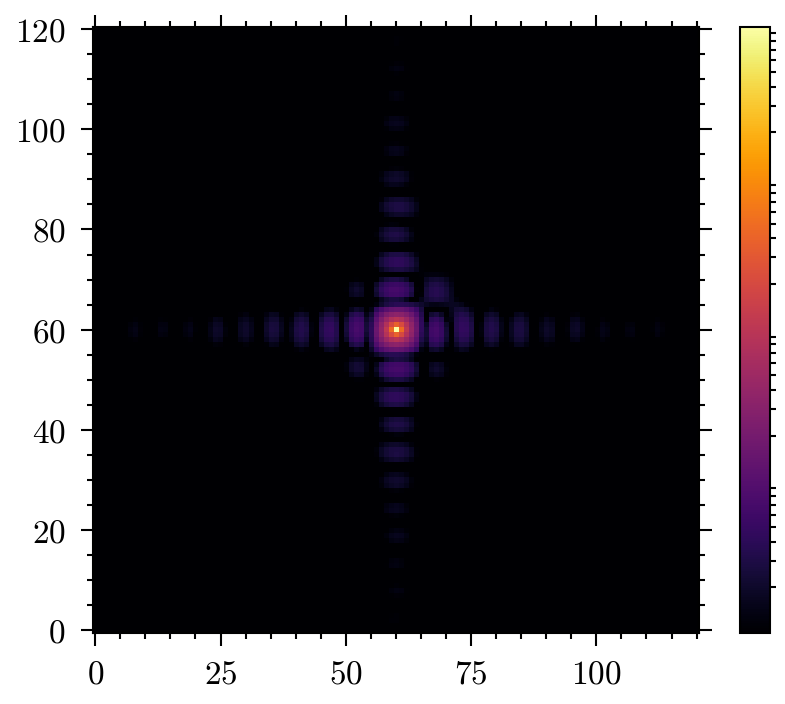

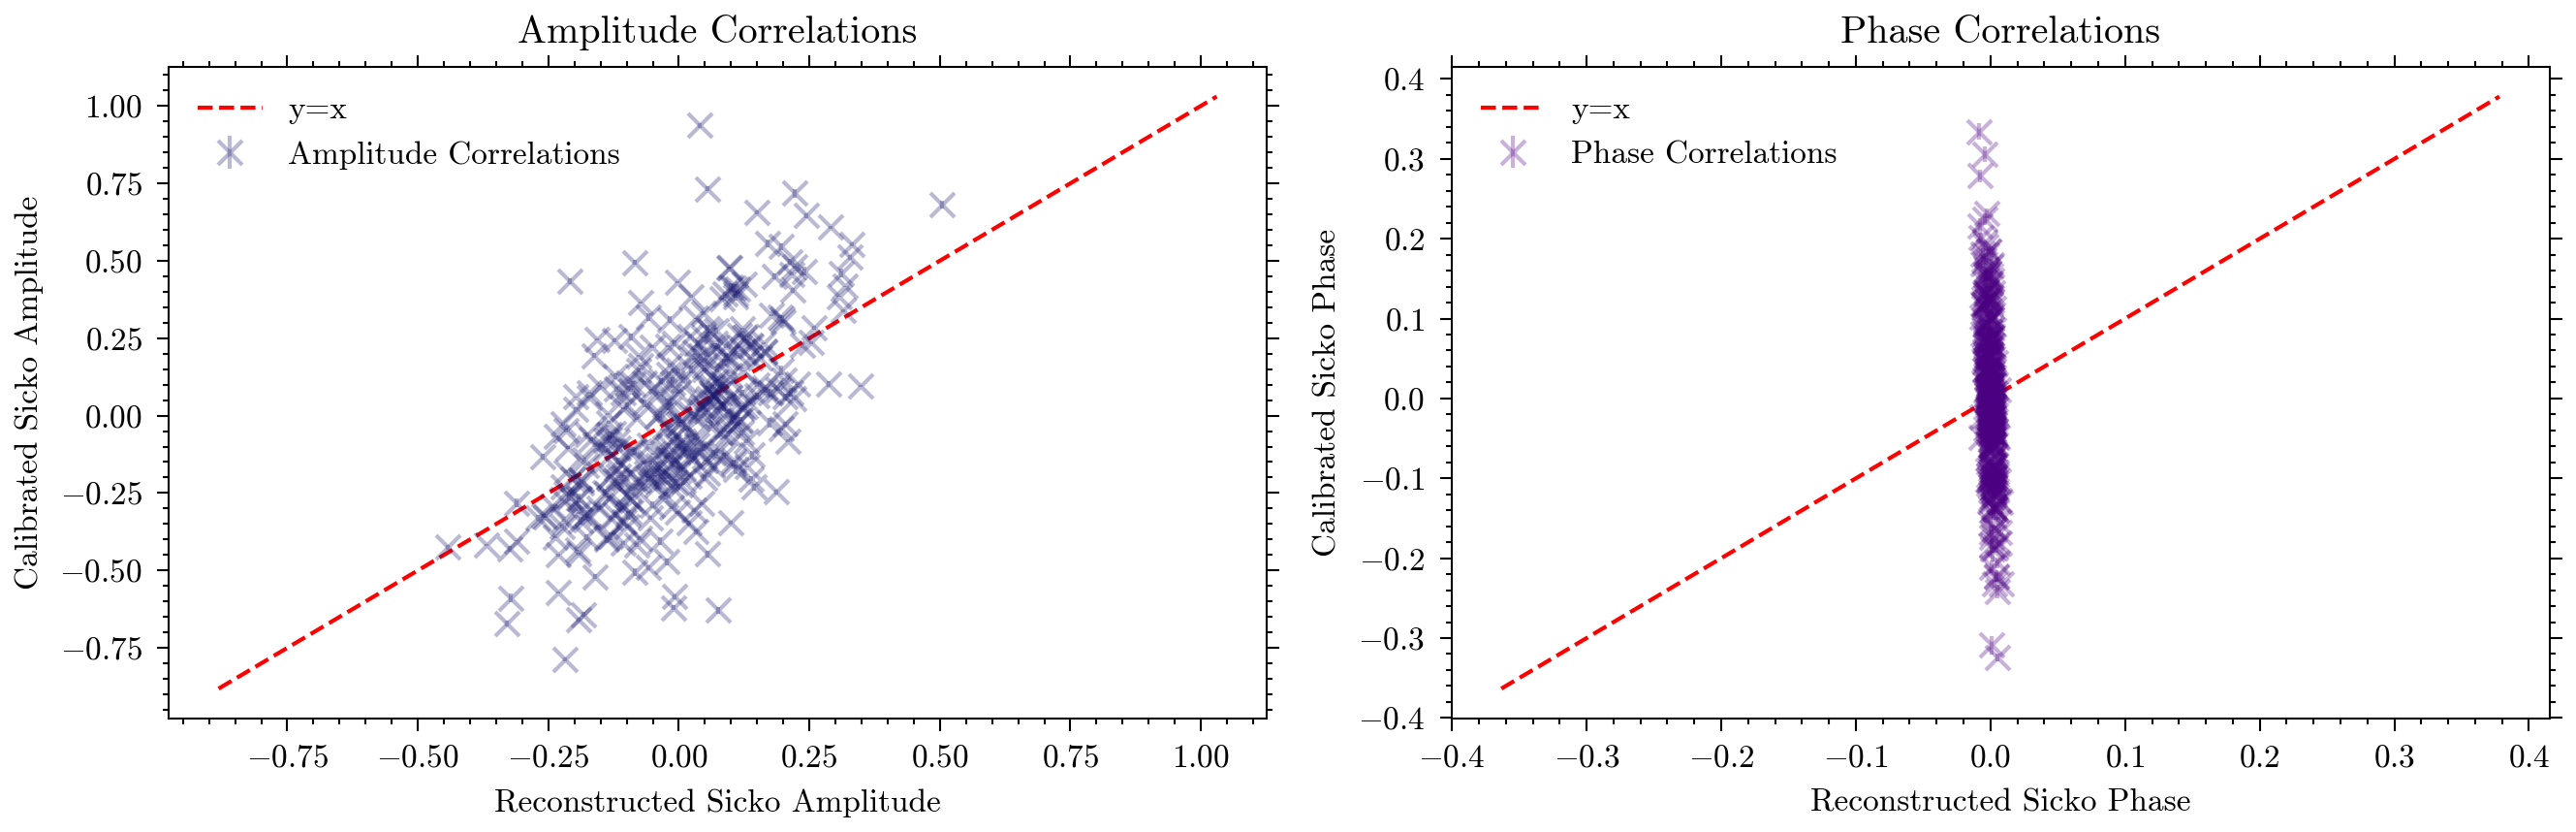

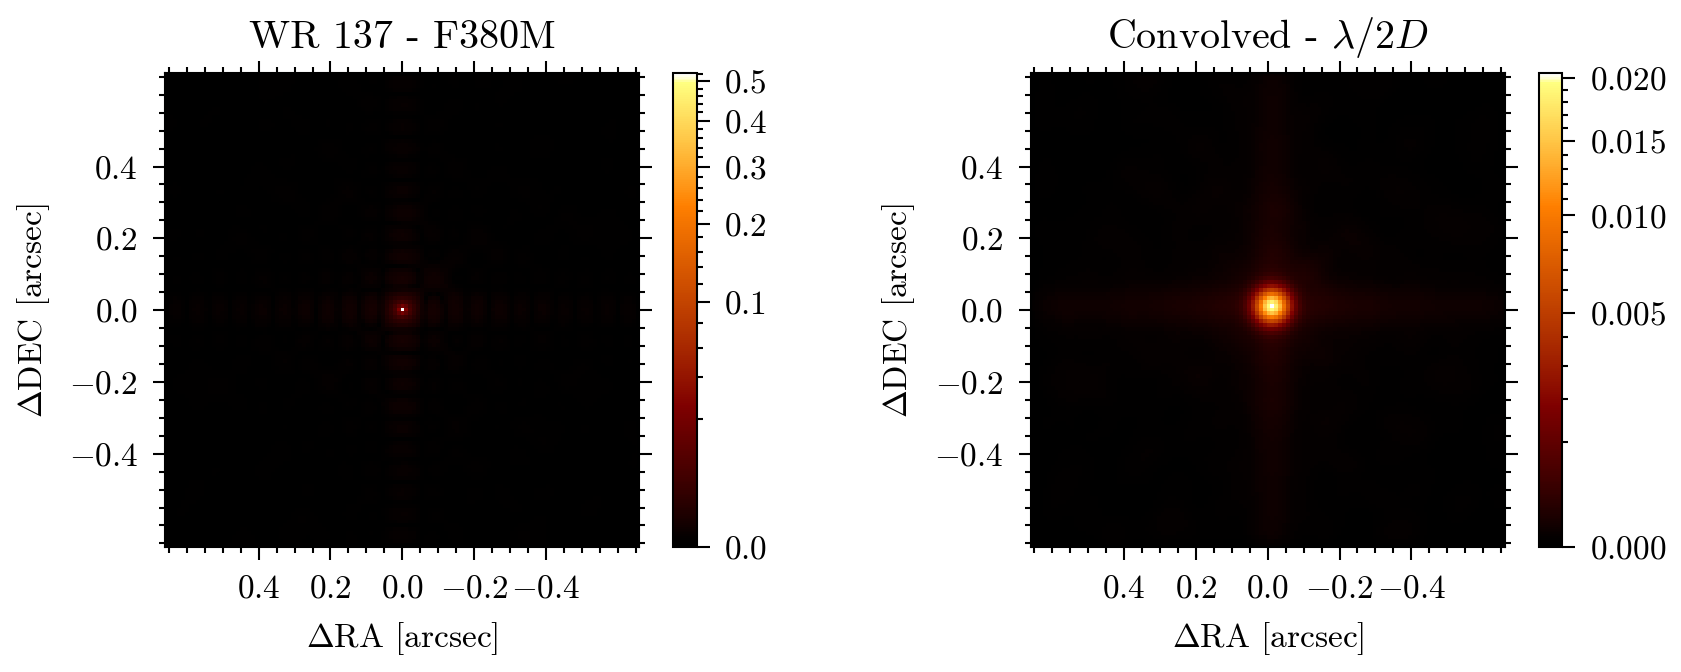

0.9999753


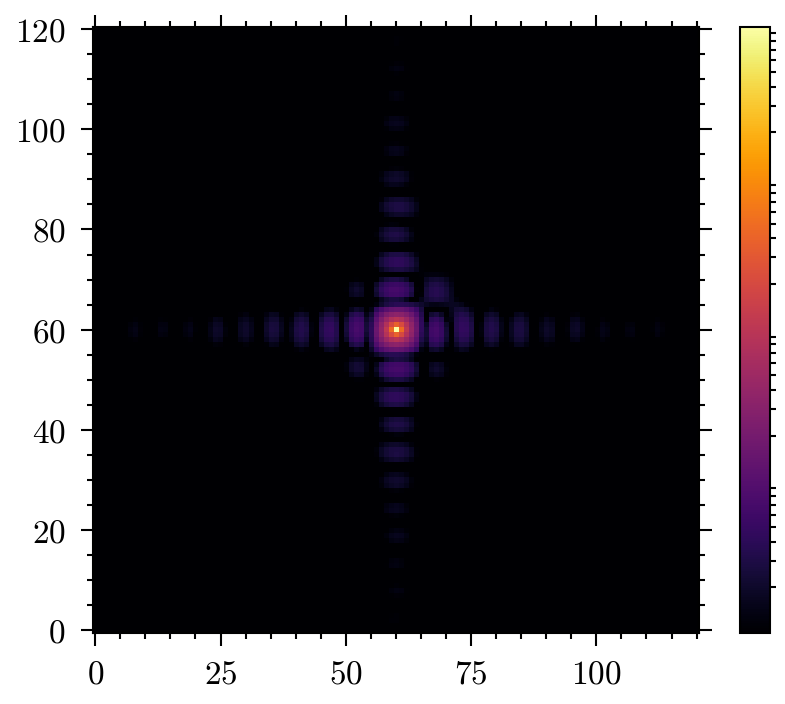

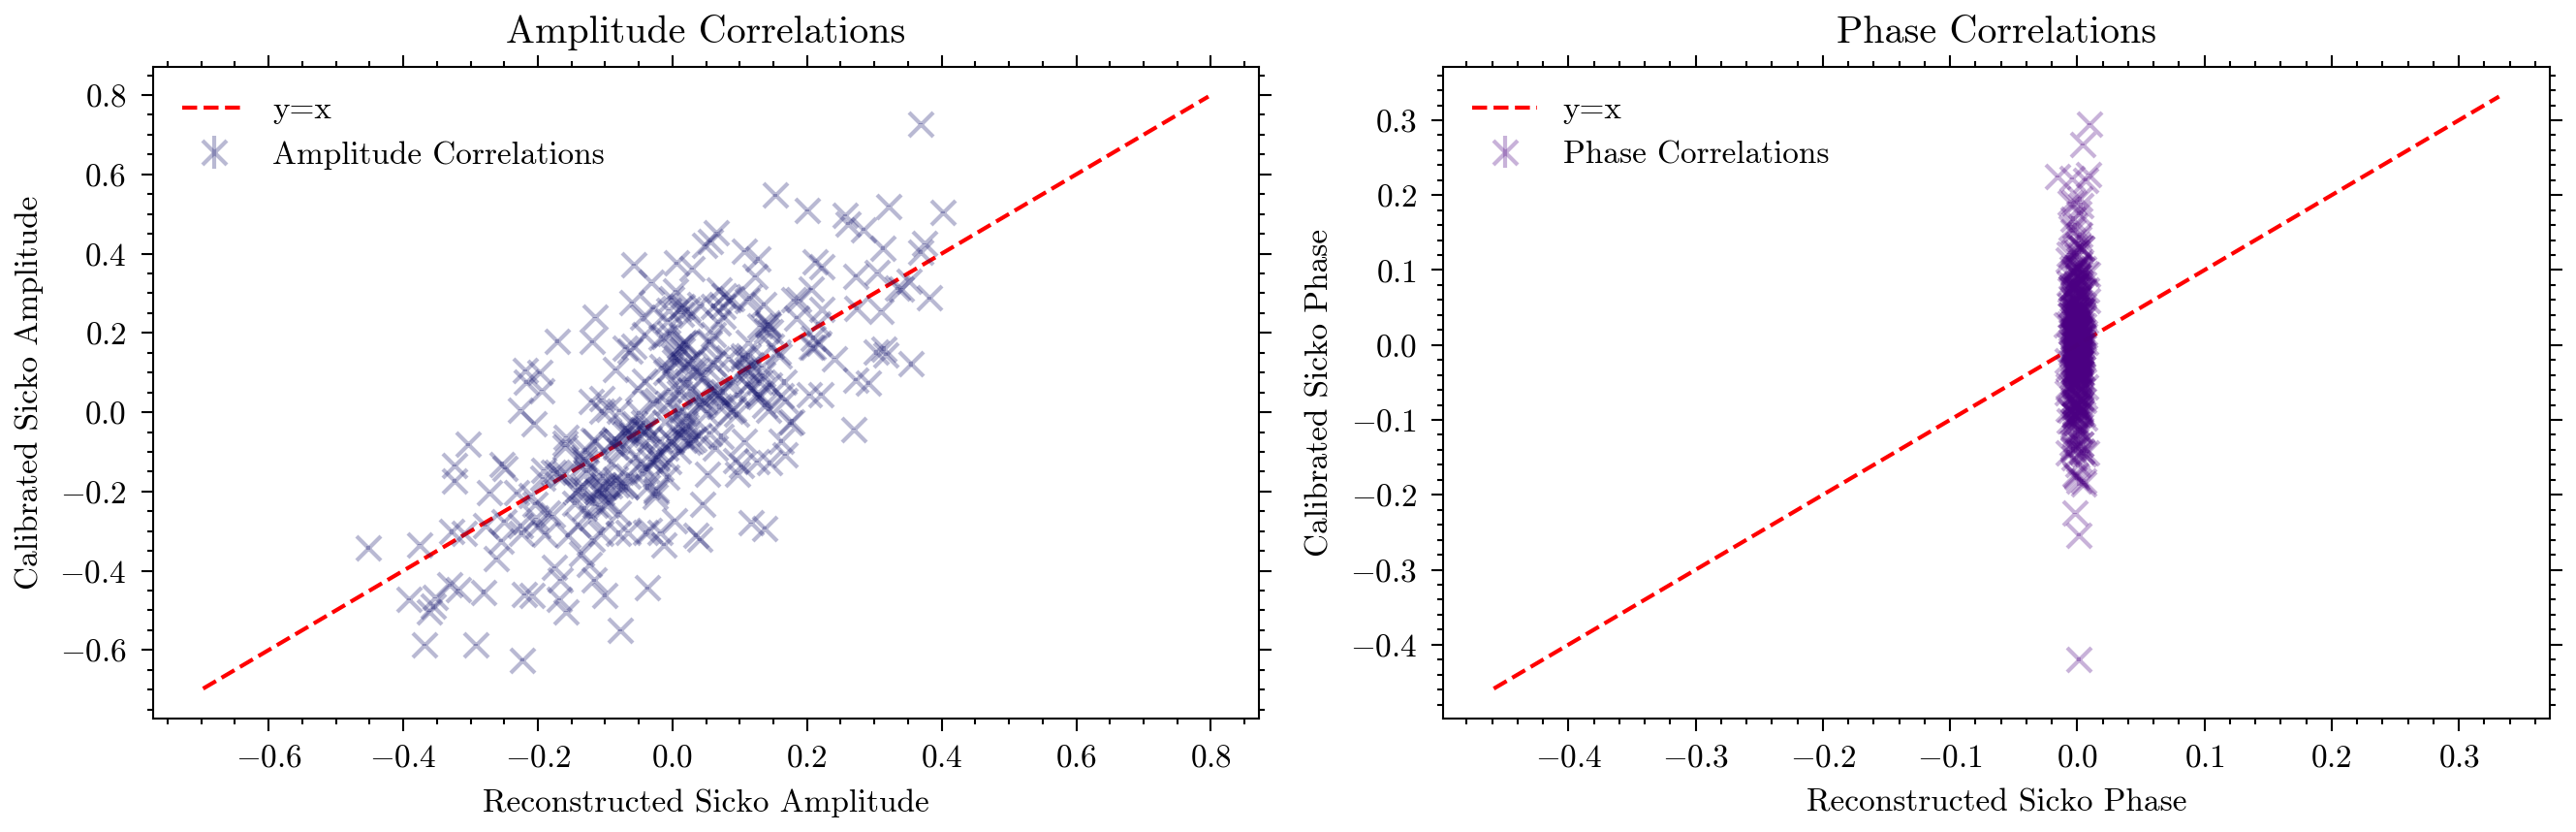

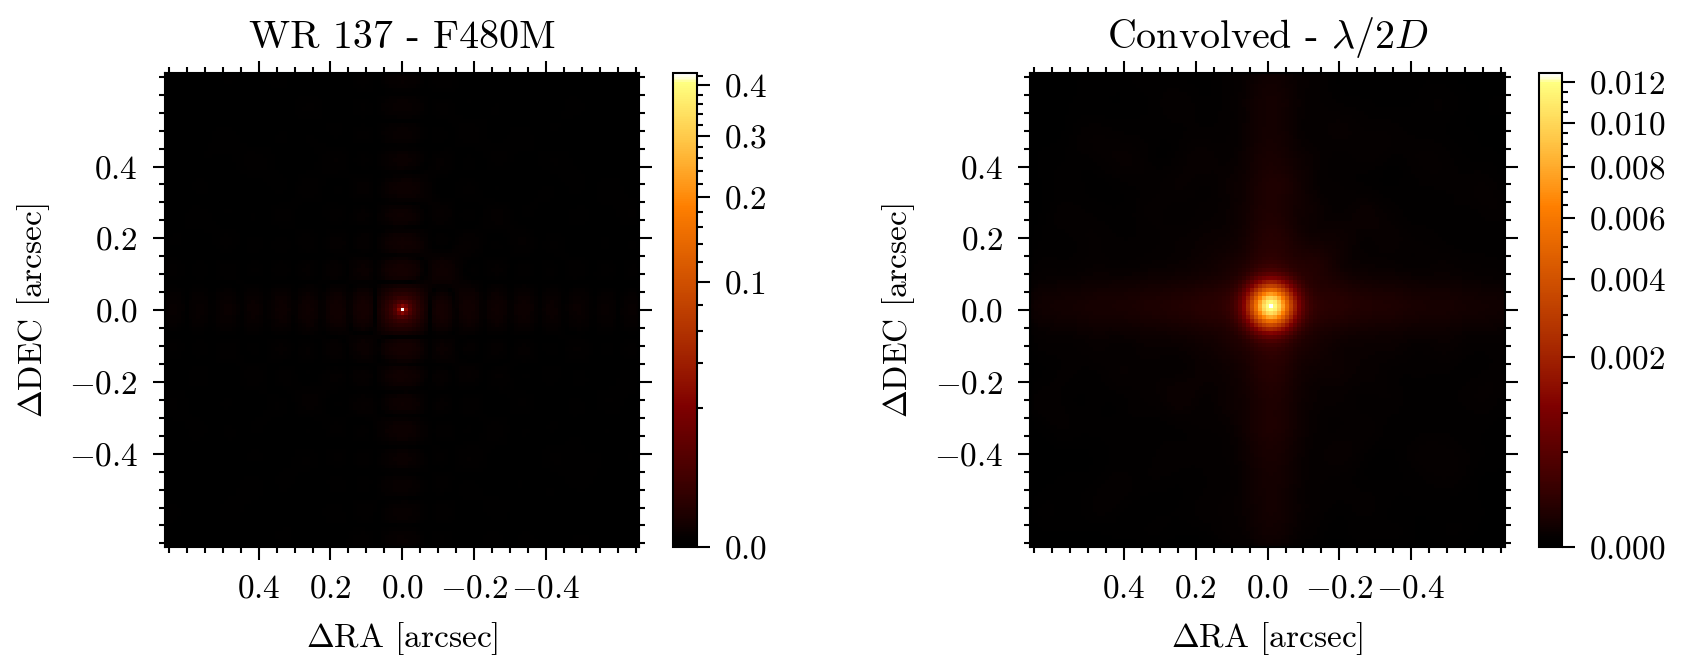

0.9999738


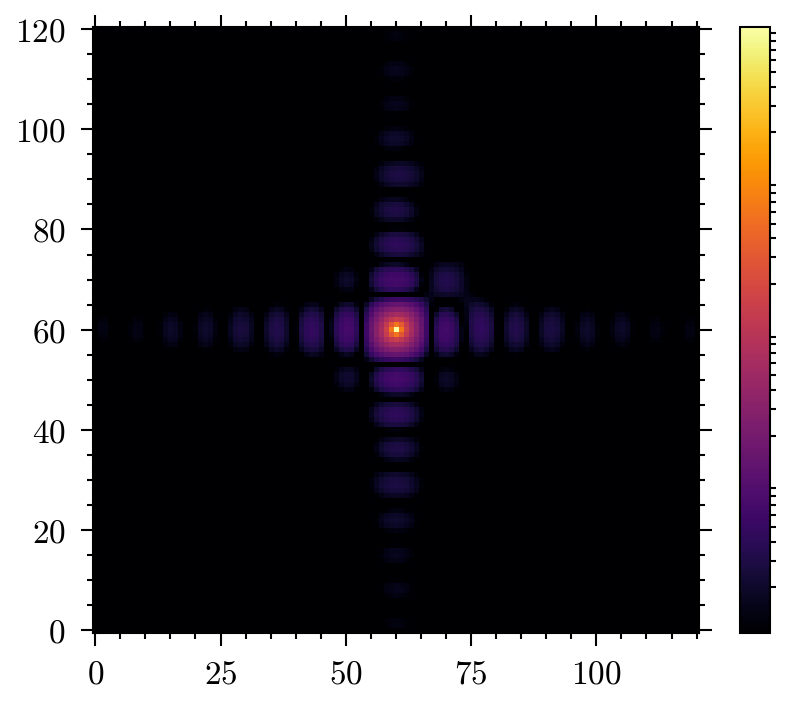

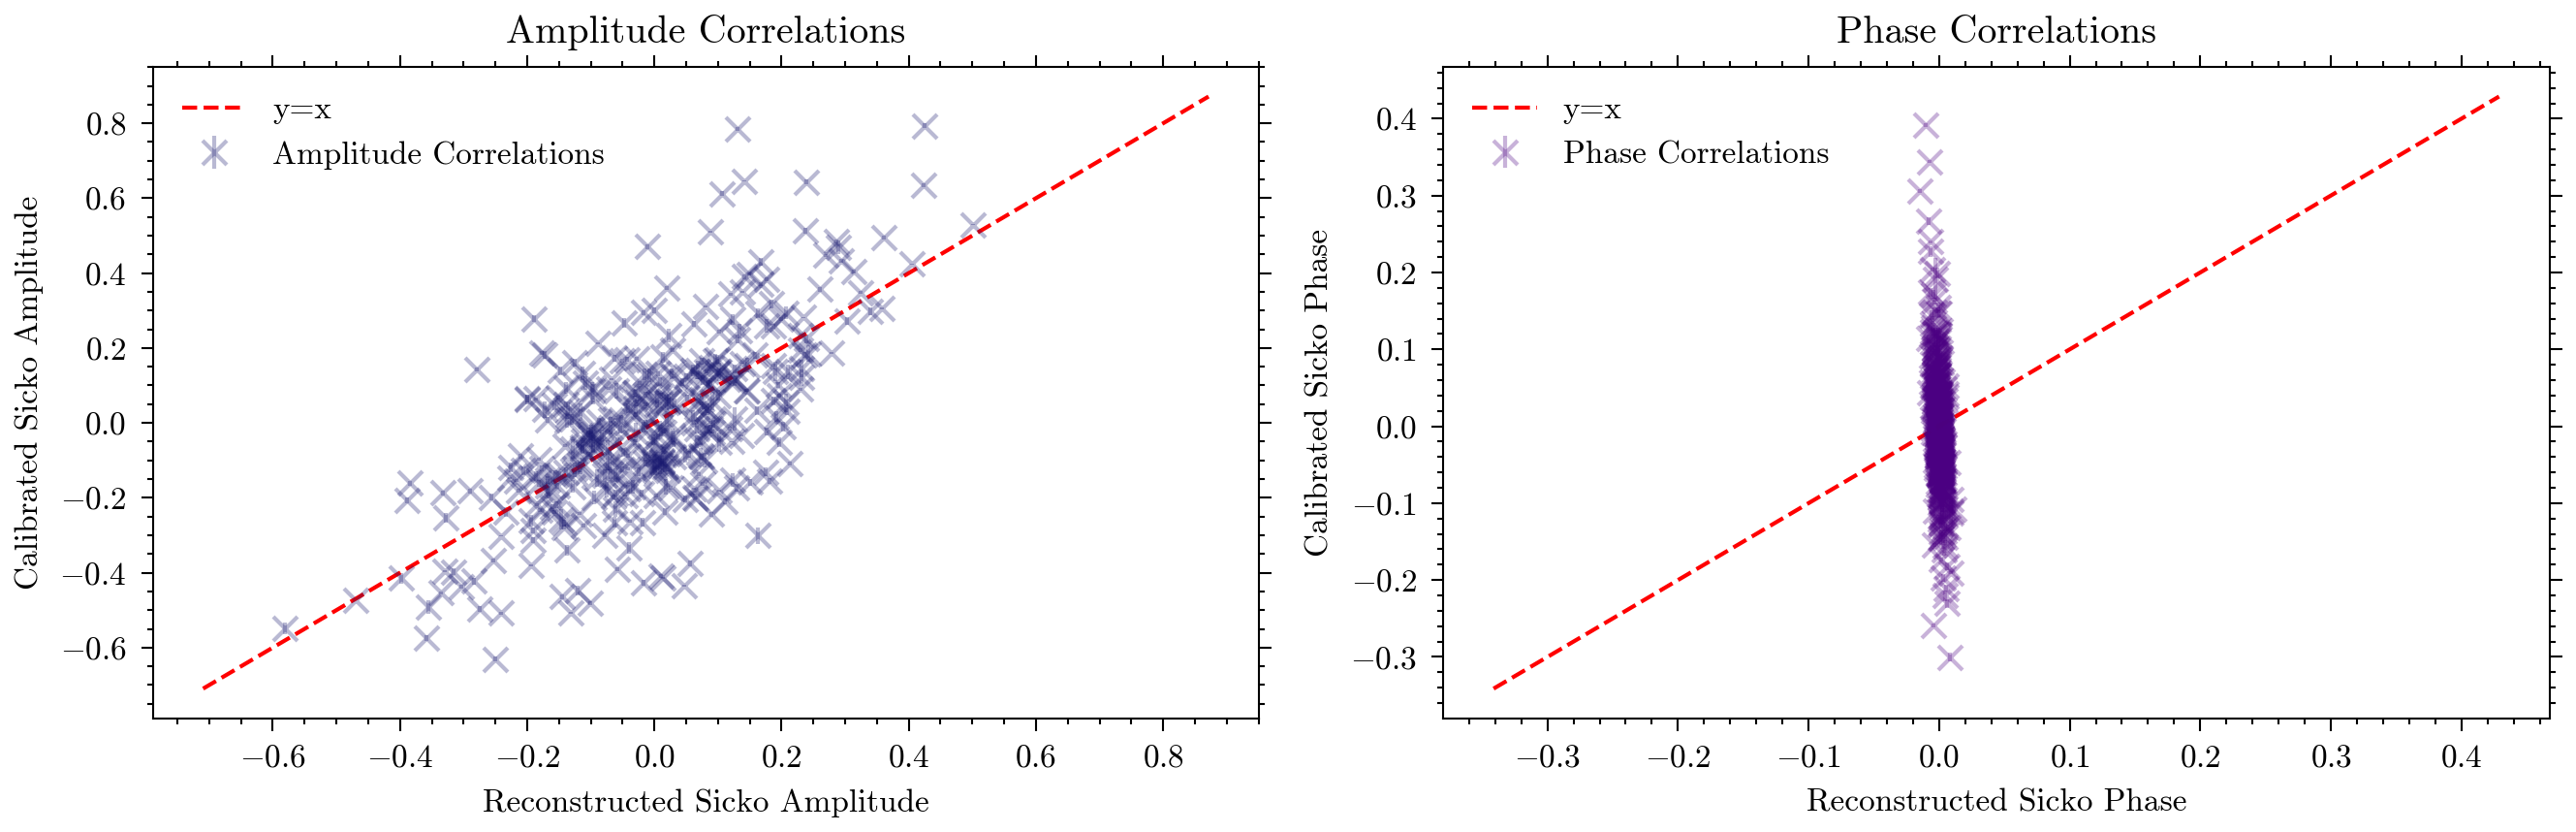

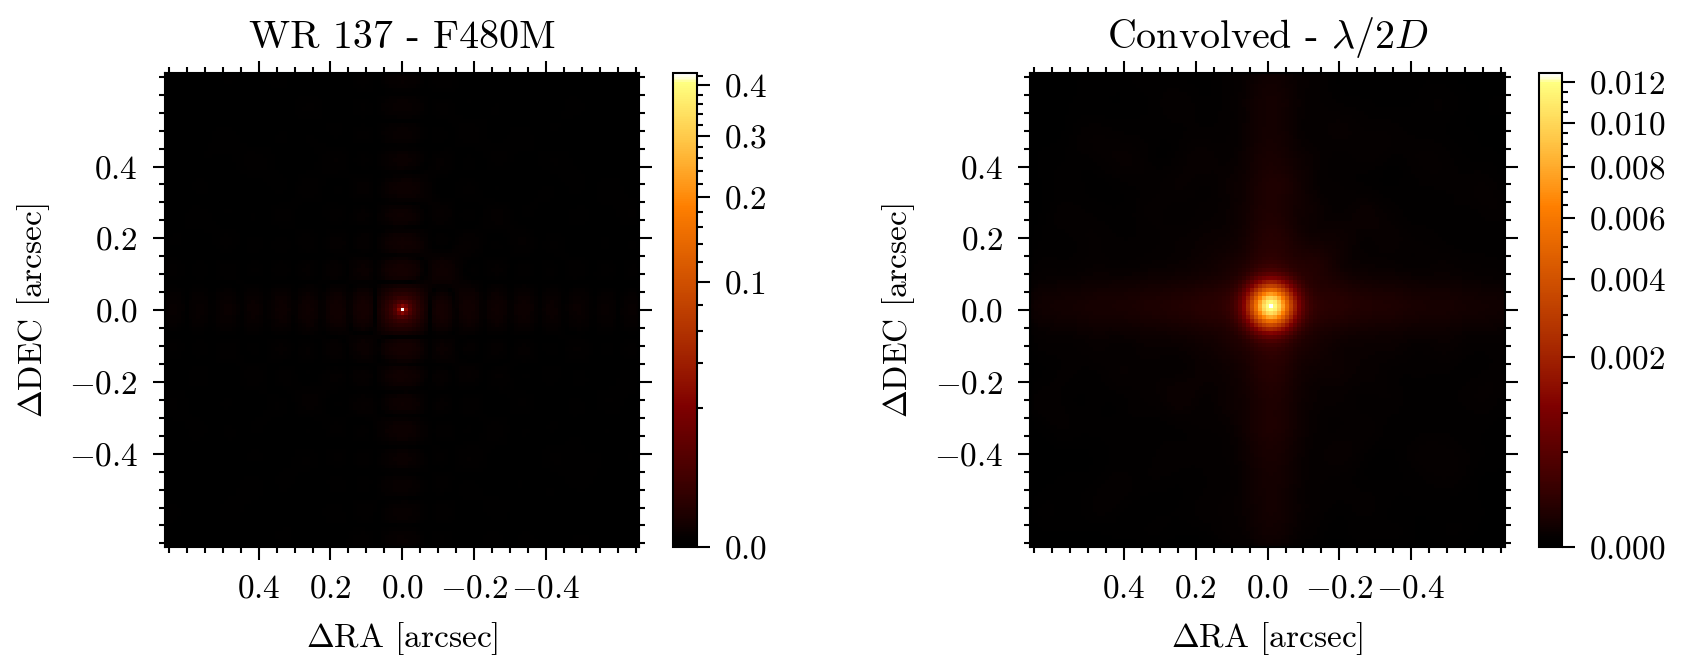

0.9999738


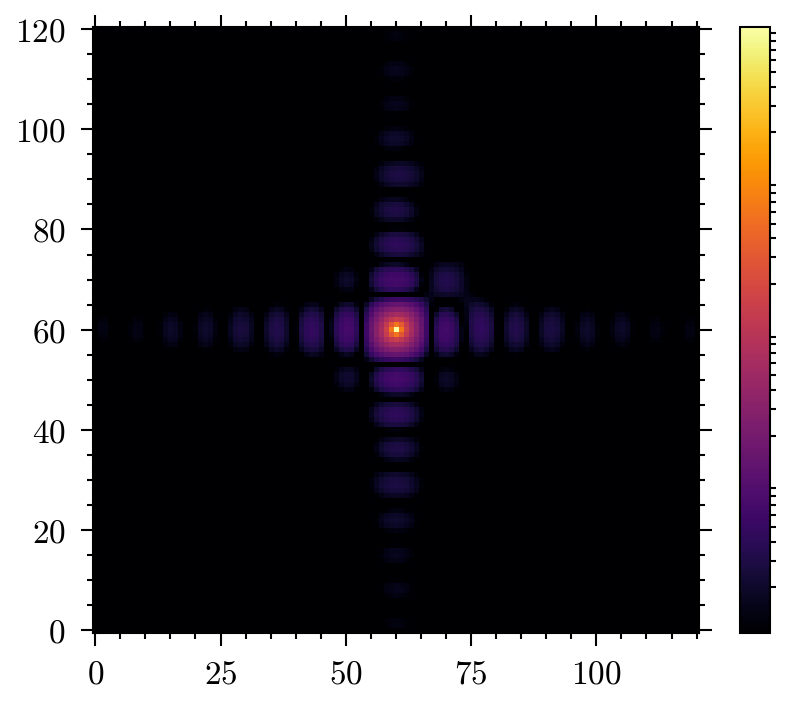

In [19]:
for oi in ois:
    dist = 10 ** bfgs_model.params["log_dist"][oi.get_key("log_dist")]

    sicko_amp, sicko_phase = oi(bfgs_model)

    fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharey=False)

    ax[0].errorbar(
        sicko_amp,
        oi.vis,
        yerr=oi.d_vis,
        label="Amplitude Correlations",
        fmt="x",
        alpha=0.3,
        color="midnightblue",
    )
    x_min, x_max = ax[0].get_xlim()
    y_min, y_max = ax[0].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[0].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[0].set_title("Amplitude Correlations")
    ax[0].set_xlabel("Reconstructed Sicko Amplitude")
    ax[0].set_ylabel("Calibrated Sicko Amplitude")
    ax[0].legend()

    ax[1].errorbar(
        sicko_phase,
        oi.phi,
        yerr=oi.d_phi,
        label="Phase Correlations",
        fmt="x",
        alpha=0.3,
        color="indigo",
    )
    x_min, x_max = ax[1].get_xlim()
    y_min, y_max = ax[1].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[1].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[1].set_title("Phase Correlations")
    ax[1].set_xlabel("Reconstructed Sicko Phase")
    ax[1].set_ylabel("Calibrated Sicko Phase")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    ticks = [-0.4, -0.2, 0, 0.2, 0.4]

    fig, ax = plt.subplots(1, 2, figsize=(6, 2.3))

    c0 = dorito.plotting.plot_result(
        ax[0],
        dist,
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_u",
        power=0.4,
        vmin=0,
        ticks=ticks,
    )

    c1 = dorito.plotting.plot_result(
        ax[1],
        blur_distribution(dist, model, oi, factor=0.5),
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_u",
        power=0.5,
        vmin=None,
        ticks=ticks,
    )
    fig.colorbar(c1, ax=ax[1])

    fig.colorbar(c0)
    # pa = model.params["position_angles"][exp.key]
    ax[0].set_title(
        f"WR 137 - {oi.filter}"  # - {model.params['position_angles'][exp.get_key('position_angles')]:.1f}deg"
    )
    ax[1].set(title=r"Convolved - $\lambda / 2D$")

    plt.tight_layout()
    # plt.savefig(output_path + f"{time}.png", dpi=300)
    # plt.close()
    plt.show()

    print(dist.sum())

    rl_dist = np.clip(dist + 1e-16)
    rl_dist = rl_dist / rl_dist.max()
    plt.imshow(rl_dist, norm=mpl.colors.LogNorm(vmin=1e-4, vmax=1.0))
    plt.colorbar(ticks=[])
    plt.show()

In [20]:
params = bfgs_model.params
for oi in ois:
    dist = 10 ** params["log_dist"][oi.get_key("log_dist")]
    blurred_dist = blur_distribution(dist, bfgs_model, oi, factor=0.01)
    params["log_dist"][oi.get_key("log_dist")] = np.log10(
        blurred_dist / blurred_dist.sum()
    )

reg_model = bfgs_model.set("params", params)

In [21]:
n_epoch = 15000

config = {
    # "log_dist": sgd(5e-8, 0, (500, 0.5)),
    # "log_dist": sgd(3e-800, 0),
    "log_dist": sgd(1e-8, 0),
    # "log_dist": sgd(1e-8, 0, (100, 10), (2000, 0.5)),
    # "log_dist": adam(1e-2, 0, (500, 2)),
    # "log_dist": sgd(5e-9, 0, (500, 2), (1000, 2)),
    # "log_dist": sgd(1e-8, 0, (10, 5), (500, 0.25), (1000, 1.5), (1300, 0.75)),
}

args = {
    "reg_func_dict": {
        "ME": dorito.stats.ME,
        "TV": dorito.stats.TV,
        "L2": dorito.stats.L2,
        "TSV": dorito.stats.TSV,
    },
    "reg_dict": {
        # "ME": 5e5,
        # "TV": 1.0,
        # "L2": 1e-5,
        # "TSV": 1e12,
        "TSV": 5e6,
    },
}

trainer = amigo.fitting.Trainer(
    loss_fn=regularised_loss_fn,
    cache=fisher_cache,
    # grad_fn=grad_fn,
    norm_fn=normalise_distribution,
    looper_fn=looper,
)

trainer = trainer.update_fishers(
    model=reg_model,
    exposures=[],
    parameters=[],
)

# Train the model
result = trainer.train(
    model=reg_model,
    optimisers=config,
    epochs=n_epoch,
    batches=ois,
    args=args,
    # batches=exposures,
)

NameError: name 'fisher_cache' is not defined

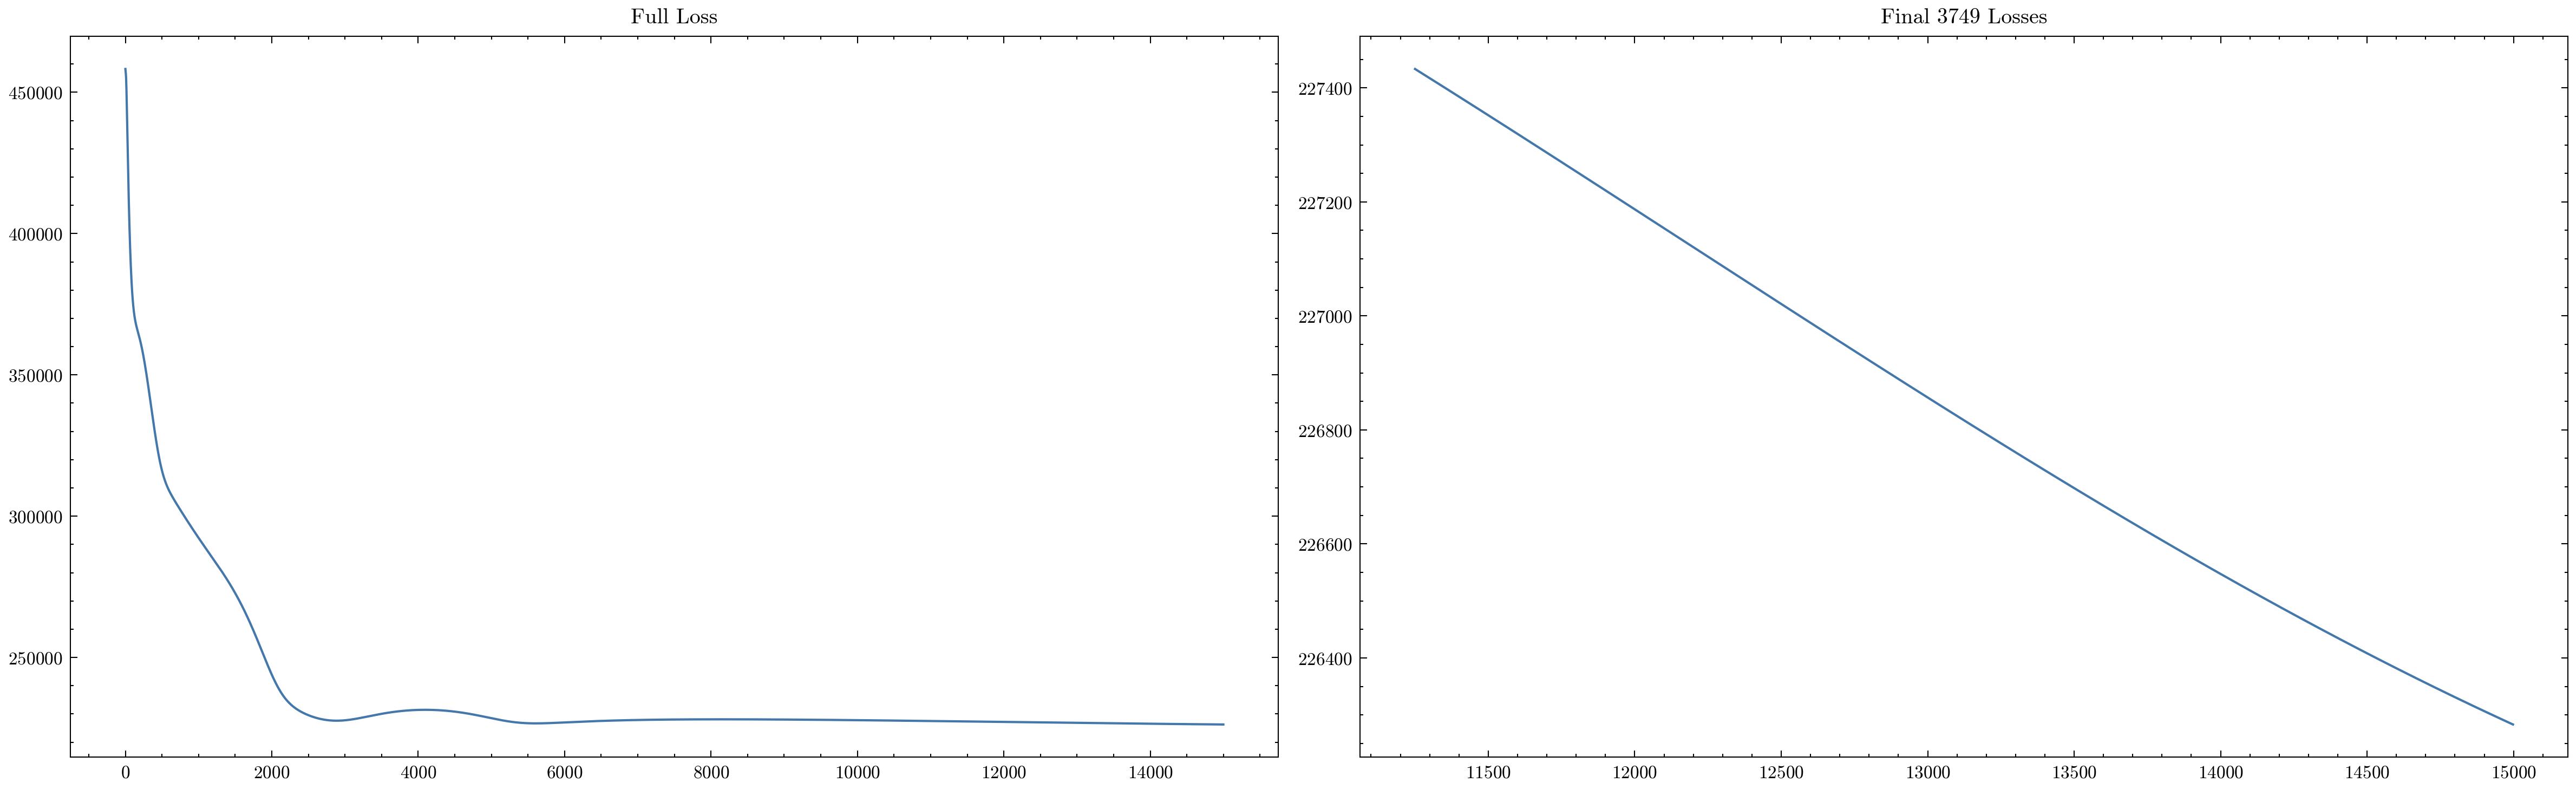

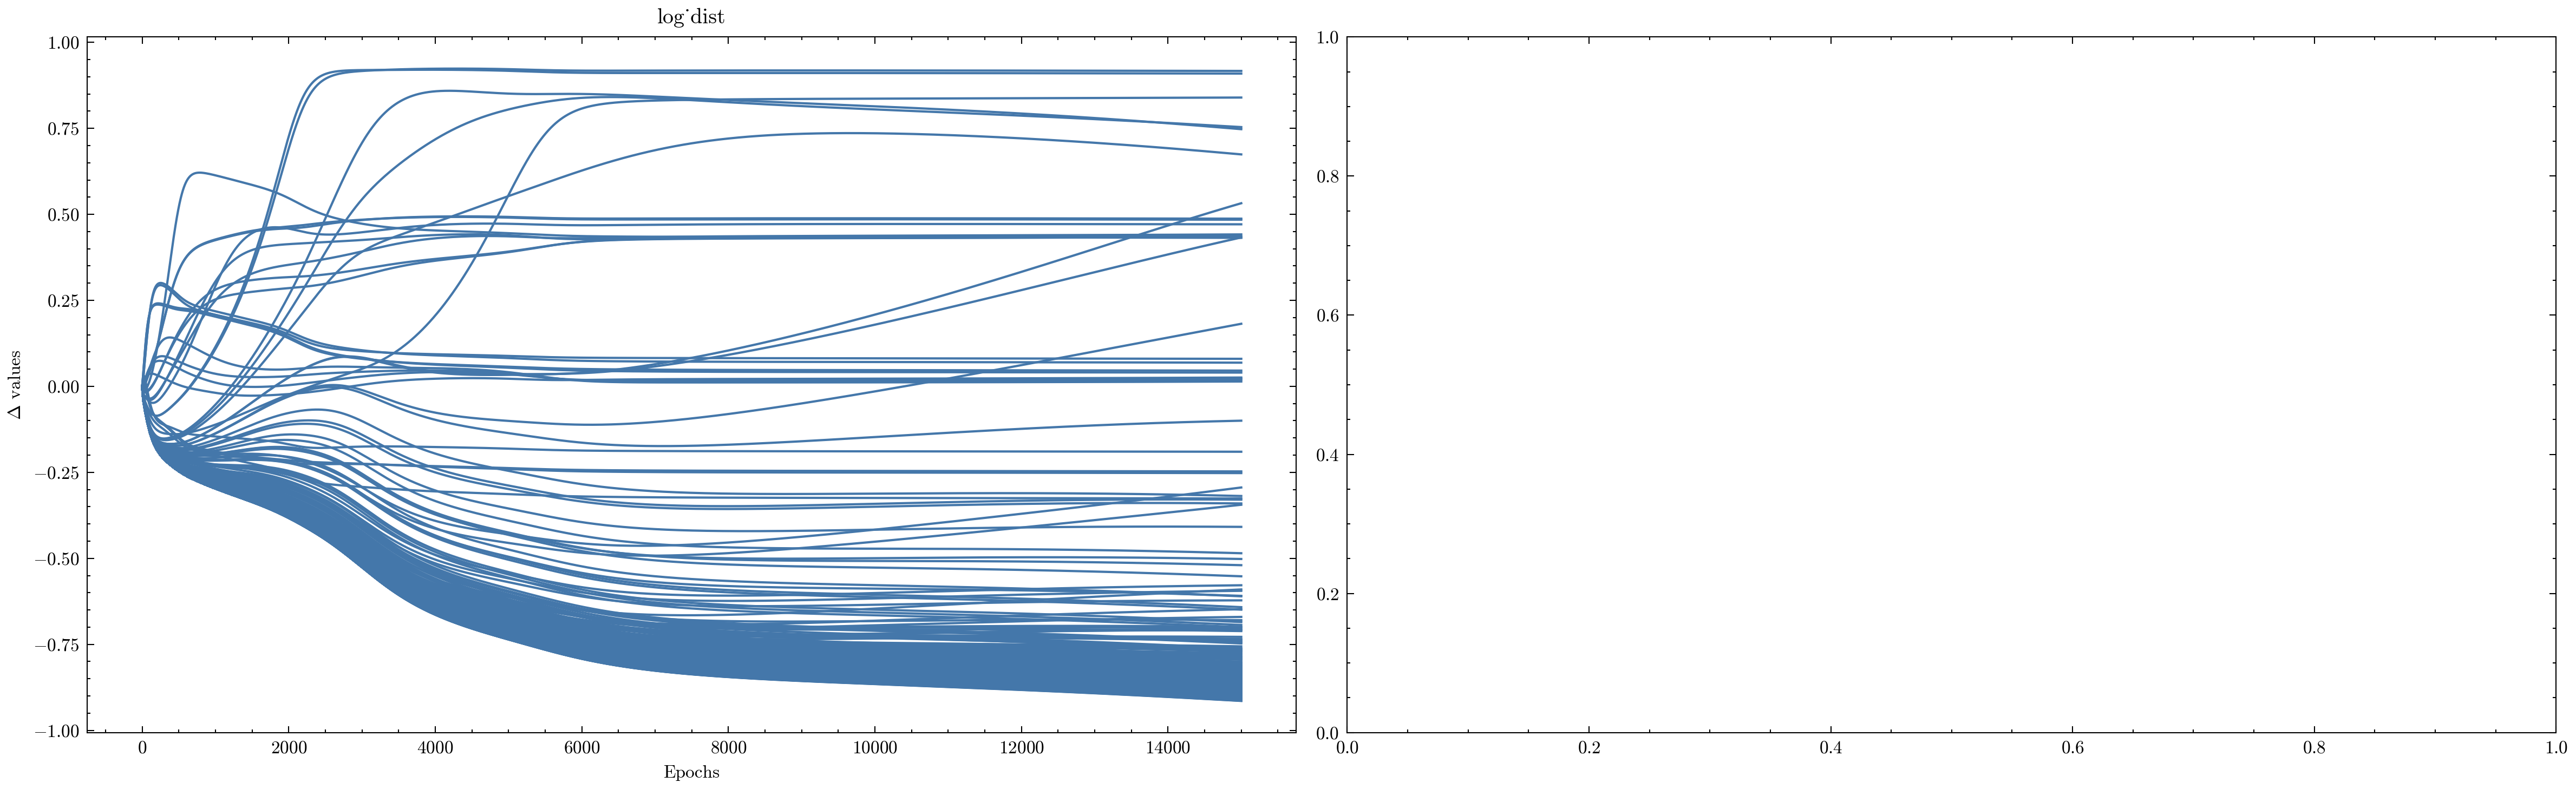

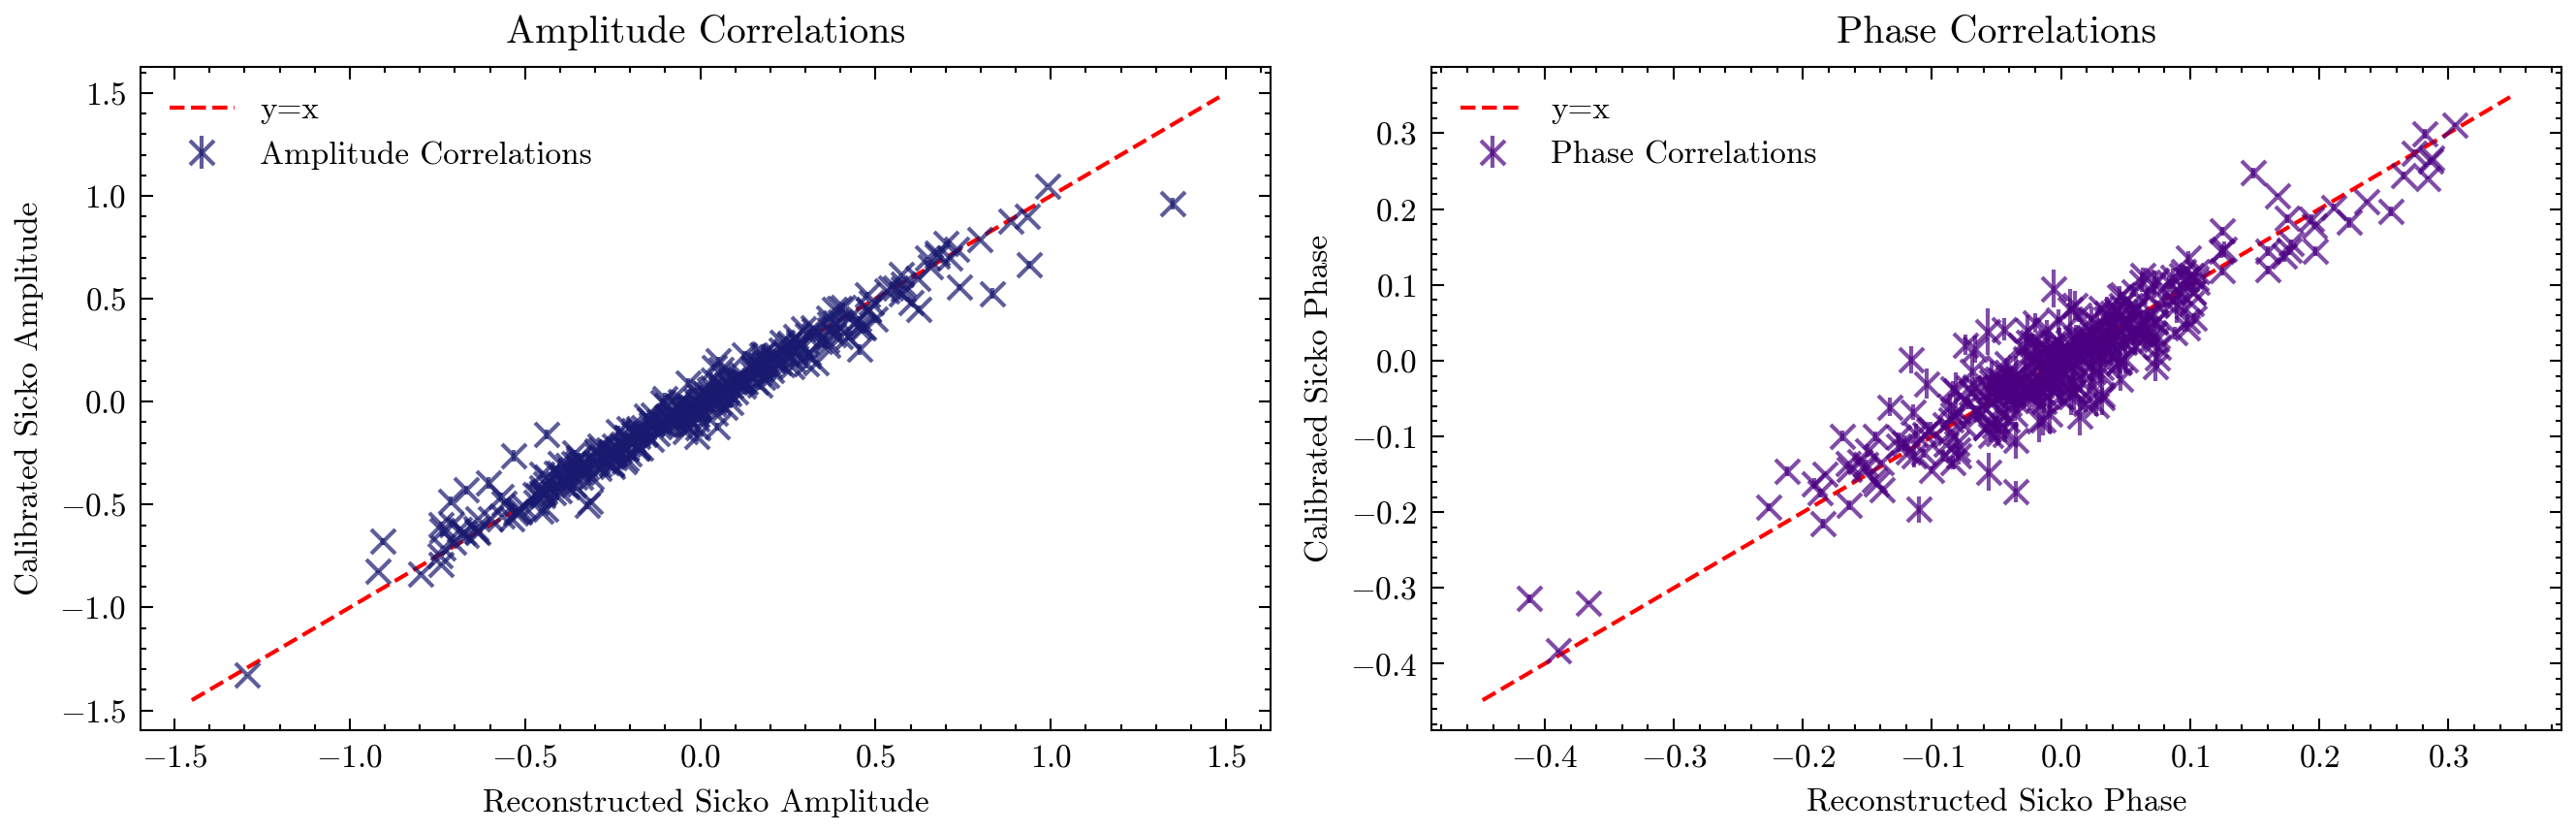

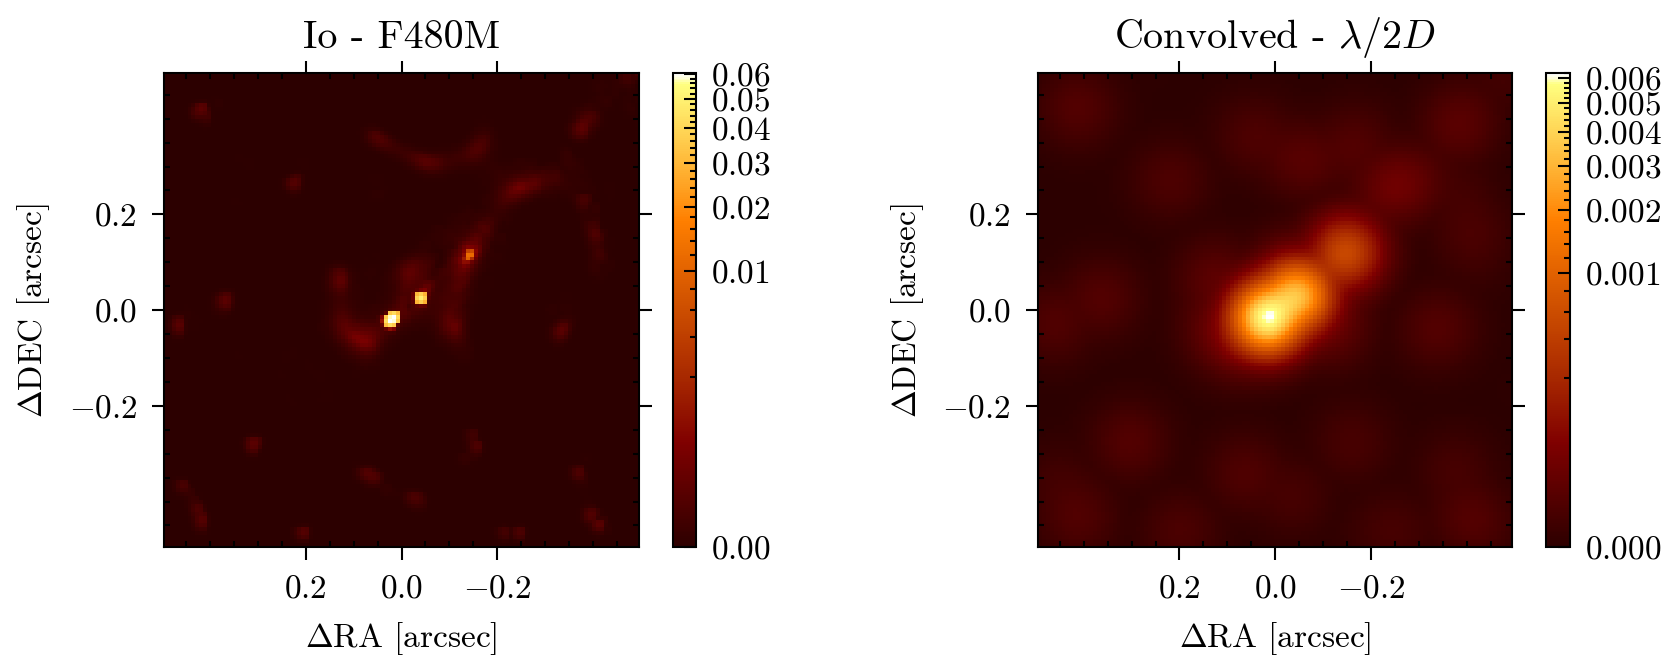

In [ ]:
amigo.plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
amigo.plotting.plot(result.history)

for oi in ois:
    dist = 10 ** result.model.params["log_dist"][oi.get_key("log_dist")]

    sicko_amp, sicko_phase = oi(result.model)

    fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharey=False)

    ax[0].errorbar(
        sicko_amp,
        oi.vis,
        yerr=oi.d_vis,
        label="Amplitude Correlations",
        fmt="x",
        alpha=0.7,
        color="midnightblue",
    )
    x_min, x_max = ax[0].get_xlim()
    y_min, y_max = ax[0].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[0].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[0].set_title("Amplitude Correlations")
    ax[0].set_xlabel("Reconstructed Sicko Amplitude")
    ax[0].set_ylabel("Calibrated Sicko Amplitude")
    ax[0].legend()

    ax[1].errorbar(
        sicko_phase,
        oi.phi,
        yerr=oi.d_phi,
        label="Phase Correlations",
        fmt="x",
        alpha=0.7,
        color="indigo",
    )
    x_min, x_max = ax[1].get_xlim()
    y_min, y_max = ax[1].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[1].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[1].set_title("Phase Correlations")
    ax[1].set_xlabel("Reconstructed Sicko Phase")
    ax[1].set_ylabel("Calibrated Sicko Phase")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    ticks = [-0.2, 0, 0.2]

    fig, ax = plt.subplots(1, 2, figsize=(6, 2.3))

    c0 = dorito.plotting.plot_result(
        ax[0],
        dist,
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_10u",
        power=0.3,
        vmin=0,
        ticks=ticks,
    )

    c1 = dorito.plotting.plot_result(
        ax[1],
        blur_distribution(dist, model, oi, factor=0.5),
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_10u",
        power=0.3,
        vmin=None,
        ticks=ticks,
    )
    fig.colorbar(c1, ax=ax[1])

    fig.colorbar(c0)
    # pa = model.params["position_angles"][exp.key]
    ax[0].set_title(
        f"Io - {oi.filter}"  # - {model.params['position_angles'][exp.get_key('position_angles')]:.1f}deg"
    )
    ax[1].set(title=r"Convolved - $\lambda / 2D$")

    plt.tight_layout()
    # plt.savefig(output_path + f"{time}.png", dpi=300)
    # plt.close()
    plt.show()

In [ ]:
last_model = BFGS_logdist(
    model=result.model,
    exposures=ois,
    reg_args=args,
    max_steps=2**16,
)

Initial loss: 226282.70181366627


E0514 15:47:42.703019 2159313 pjrt_stream_executor_client.cc:2839] Execution of replica 0 failed: INTERNAL: CpuCallback error calling callback: Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/media/data/max/anaconda3/envs/ami/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
  File "/media/data/max/anaconda3/envs/ami/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
  File "/media/data/max/anaconda3/envs/ami/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start
  File "/media/data/max/anaconda3/envs/ami/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 205, in start
  File "/media/data/max/anaconda3/envs/ami/lib/python3.11/asyncio/base_events.py", line 608, in run_forever
  File "/media/data/max/anaconda3/envs/ami/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once
  File "/me

EquinoxRuntimeError: Above is the stack outside of JIT. Below is the stack inside of JIT:
  File "/media/data/max/anaconda3/envs/ami/lib/python3.11/site-packages/optimistix/_minimise.py", line 107, in minimise
    return iterative_solve(
           ^^^^^^^^^^^^^^^^
  File "/media/data/max/anaconda3/envs/ami/lib/python3.11/site-packages/optimistix/_iterate.py", line 351, in iterative_solve
    sol = result.error_if(sol, result != RESULTS.successful)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
equinox.EquinoxRuntimeError: The maximum number of steps was reached in the nonlinear solver. The problem may not be solveable (e.g., a root-find on a function that has no roots), or you may need to increase `max_steps`.

-------------------

An error occurred during the runtime of your JAX program.

1) Setting the environment variable `EQX_ON_ERROR=breakpoint` is usually the most useful
way to debug such errors. This can be interacted with using most of the usual commands
for the 